In [40]:
import math
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from matplotlib.lines import Line2D
from pathlib import Path


pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")

In [41]:

#drive.mount('/content/drive')

#ruta_archivo = Path("/content/drive/MyDrive/Semillero - Proyecto ML/proyecto_ml_py/Saber11_limpio.csv") # Assuming the file is in the root of MyDrive
#df = pd.read_csv(ruta_archivo, sep=";", encoding="utf-8")

ruta_archivo = Path("../data/processed/Saber11_limpio.csv")
df = pd.read_csv(ruta_archivo, sep=";", encoding="utf-8")

df.columns = df.columns.str.strip()
objetivo = "punt_global"
areas = [
    "punt_c_naturales",
    "punt_ingles",
    "punt_lectura_critica",
    "punt_matematicas",
    "punt_sociales_ciudadanas",
]

for columna in [objetivo, *areas]:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")
print(f"Objetivo: {objetivo} | Media: {df[objetivo].mean():.2f}")
df.head()

Filas: 169,004 | Columnas: 38
Objetivo: punt_global | Media: 256.47


,periodo,cole_area_ubicacion,cole_caracter,cole_jornada,cole_mcpio_ubicacion,cole_naturaleza,estu_dedicacioninternet,estu_dedicacionlecturadiaria,estu_genero,estu_horassemanatrabaja,estu_mcpio_reside,fami_comecarnepescadohuevo,fami_comecerealfrutoslegumbre,fami_comelechederivados,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_numlibros,fami_personashogar,fami_situacioneconomica,fami_tieneautomovil,fami_tienecomputador,fami_tieneconsolavideojuegos,fami_tienehornomicroogas,fami_tieneinternet,fami_tienelavadora,fami_tienemotocicleta,fami_tieneserviciotv,fami_trabajolabormadre,fami_trabajolaborpadre,punt_c_naturales,punt_global,punt_ingles,punt_lectura_critica,punt_matematicas,punt_sociales_ciudadanas,Año
0,20222,rural,tecnicoacademico,noche,cali,oficial,30minutosomenos,entre1y2horas,m,0,cali,todosocasitodoslosdias,3a5vecesporsemana,todosocasitodoslosdias,uno,tecnicaotecnologicacompleta,tecnicaotecnologicacompleta,estrato3,0a10libros,3a4,peor,no,no,no,no,si,no,no,si,trabajacomopersonaldelimpiezamantenimientosegu...,noaplica,32,203,50.0,47,42,38,2022
1,20222,urbano,tecnico,completa,cali,nooficial,entre1y3horas,noleoporentretenimiento,m,0,cali,todosocasitodoslosdias,1o2vecesporsemana,3a5vecesporsemana,dos,secundariabachilleratocompleta,tecnicaotecnologicacompleta,estrato1,11a25libros,3a4,igual,si,si,si,si,si,si,si,si,nosabe,trabajaporcuentapropiaporejemploplomeroelectri...,44,224,52.0,48,47,38,2022
2,20222,urbano,academico,unica,cali,oficial,entre1y3horas,noleoporentretenimiento,f,0,cali,3a5vecesporsemana,todosocasitodoslosdias,3a5vecesporsemana,tres,primariacompleta,primariaincompleta,estrato2,0a10libros,5a6,igual,no,no,no,no,si,si,si,si,trabajacomopersonaldelimpiezamantenimientosegu...,trabajaporcuentapropiaporejemploplomeroelectri...,43,223,35.0,53,46,40,2022
3,20222,urbano,tecnicoacademico,tarde,cali,nooficial,entre30y60minutos,30minutosomenos,f,0,cali,1o2vecesporsemana,nuncaoraravezcomemoseso,nuncaoraravezcomemoseso,dos,primariaincompleta,nosabe,estrato1,0a10libros,5a6,igual,no,si,no,no,si,no,no,si,noaplica,noaplica,46,235,37.0,48,49,48,2022
4,20222,rural,tecnicoacademico,manana,palmira,oficial,masde3horas,entre30y60minutos,f,0,palmira,3a5vecesporsemana,1o2vecesporsemana,1o2vecesporsemana,dos,secundariabachilleratocompleta,tecnicaotecnologicacompleta,estrato1,11a25libros,3a4,peor,no,no,no,no,si,si,si,si,tieneuntrabajodetipoauxiliaradministrativopore...,esduenodeunnegociopequenotienepocosempleadoson...,58,287,49.0,62,57,55,2022


In [42]:
df.describe()

,periodo,punt_c_naturales,punt_global,punt_ingles,punt_lectura_critica,punt_matematicas,punt_sociales_ciudadanas,Año
count,169004.000000,169004.000000,169004.000000,169004.000000,169004.000000,169004.000000,169004.000000,169004.000000
mean,20237.026946,50.398056,256.466036,52.345889,54.130742,51.522899,48.788419,2023.514816
std,10.937208,10.758138,52.559142,13.121635,10.553458,12.565715,12.227972,1.098580
min,20222.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022.000000
25%,20231.000000,42.000000,216.000000,43.000000,47.000000,43.000000,39.000000,2023.000000
50%,20241.000000,50.000000,254.000000,51.000000,54.000000,52.000000,48.000000,2024.000000
75%,20242.000000,58.000000,294.000000,60.000000,62.000000,60.000000,58.000000,2024.000000
max,20252.000000,100.000000,494.000000,100.000000,100.000000,100.000000,100.000000,2025.000000


Mediante el discribe se puede ver que el maximo del puntaje global de los datos es 494 y la media es 256.46, ademas se ve que en promedio los estudiante evaluados les va mejor en lectura critica y peor en sociales y ciudadania

In [43]:
puntaje_anual = df.groupby("Año")["punt_global"].agg(
    cantidad="count",
    promedio="mean",
    mediana="median",
    desviacion_estandar="std"
).reset_index()

puntaje_anual

,Año,cantidad,promedio,mediana,desviacion_estandar
0,2022,39206,247.801127,245.0,49.155249
1,2023,45256,256.704326,254.0,51.878374
2,2024,42872,258.965035,257.0,53.474527
3,2025,41670,261.788697,260.0,54.408709


El puntaje global presenta una tendencia creciente durante el periodo evaluado. El promedio pasó de 247,8 en 2022 a 261,8 en 2025, lo que representa un incremento aproximado de 14 puntos, la mediana sigue el mismo comportamiento, pasando de 245 a 260 puntos, lo cual indica que el mejora en el desempeño se presenta de forma general y no únicamente por valores extremos. Por otra parte, la desviación estándar aumentó de 49,2 a 54,4, evidenciando una mayor dispersión de los resultados de los estudiante en los ultimos años registrados. Por tanto, aunque el desempeño promedio mejora, también se observa una creciente heterogeneidad entre los estudiantes o mayor variabilidad de los resultados.

In [44]:
tabla_frecuencia = df["estu_mcpio_reside"].value_counts().reset_index()
tabla_frecuencia.columns = ["Municipio", "Frecuencia"]
tabla_frecuencia["Porcentaje"] = (
    tabla_frecuencia["Frecuencia"] /
    tabla_frecuencia["Frecuencia"].sum() * 100
).round(2)
print(tabla_frecuencia)

            Municipio  Frecuencia  Porcentaje
0                cali       78552       46.48
1             palmira       13385        7.92
2        buenaventura       13240        7.83
3               tulua        8510        5.04
4             jamundi        6251        3.70
5             cartago        5506        3.26
6   guadalajaradebuga        4710        2.79
7               yumbo        4508        2.67
8          candelaria        4281        2.53
9             florida        2576        1.52
10          elcerrito        2393        1.42
11             zarzal        1866        1.10
12            pradera        1801        1.07
13              dagua        1665        0.99
14         roldanillo        1622        0.96
15            guacari        1462        0.87
16            launion        1434        0.85
17            sevilla        1382        0.82
18         caicedonia        1350        0.80
19       bugalagrande         914        0.54
20            ginebra         885 

Se puede observar que en el municipio donde mas personas que presentaron las pruebas ICFES entre 2022 y 2025 fueron personas que residian en la ciudad de Cali representando el 46.48% de la poblacion evaluada, casi la mitad de esta, en cambio estudiantes de municipios como el cairo, ulloa y versalles representan la minoria de los encuentados

In [45]:
variables_institucionales = [
    "cole_area_ubicacion",
    "cole_caracter",
    "cole_jornada",
    "cole_naturaleza",
]

for var in variables_institucionales:

    resumen = (
        df.groupby(var)["punt_global"]
        .agg(
            cantidad="count",
            promedio="mean",
            mediana="median",
            desviacion_estandar="std"
        )
    )

    # Porcentaje de observaciones
    resumen["porcentaje"] = (
        resumen["cantidad"] /
        resumen["cantidad"].sum() * 100
    )

    # Error estándar (solo para calcular el intervalo de confianza)
    error_estandar = (
        resumen["desviacion_estandar"] /
        np.sqrt(resumen["cantidad"])
    )

    # Límites del intervalo de confianza del 95 %
    limite_inferior = (
        resumen["promedio"] -
        1.96 * error_estandar
    )

    limite_superior = (
        resumen["promedio"] +
        1.96 * error_estandar
    )

    # Intervalo de confianza en una sola columna
    resumen["intervalo_confianza_95"] = (
        limite_inferior.round(2).astype(str)
        + " - "
        + limite_superior.round(2).astype(str)
    )

    # Redondear valores
    resumen["promedio"] = resumen["promedio"].round(2)
    resumen["mediana"] = resumen["mediana"].round(2)
    resumen["desviacion_estandar"] = (
        resumen["desviacion_estandar"].round(2)
    )
    resumen["porcentaje"] = resumen["porcentaje"].round(2)

    # Ordenar de mayor a menor promedio
    resumen = resumen.sort_values(
        "promedio",
        ascending=False
    )

    print("\nVariable:", var)

    display(resumen)


Variable: cole_area_ubicacion


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
cole_area_ubicacion,,,,,,
urbano,146416,258.14,256.0,52.56,86.63,257.87 - 258.41
rural,22588,245.64,240.0,51.28,13.37,244.97 - 246.31



Variable: cole_caracter


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
cole_caracter,,,,,,
academico,46339,262.02,259.0,57.48,27.42,261.49 - 262.54
tecnico,43004,256.60,254.0,50.84,25.45,256.12 - 257.08
tecnicoacademico,77500,253.34,251.0,50.01,45.86,252.99 - 253.69
noaplica,2161,246.88,243.0,54.42,1.28,244.59 - 249.17



Variable: cole_jornada


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
cole_jornada,,,,,,
completa,14812,300.38,305.0,53.65,8.76,299.51 - 301.24
manana,93735,256.27,254.0,50.08,55.46,255.95 - 256.59
unica,35292,255.94,253.0,48.94,20.88,255.43 - 256.45
tarde,13500,250.44,247.0,48.85,7.99,249.61 - 251.26
noche,6960,212.82,207.0,41.06,4.12,211.85 - 213.78
sabatina,4705,208.01,202.0,39.47,2.78,206.88 - 209.14



Variable: cole_naturaleza


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
cole_naturaleza,,,,,,
nooficial,52871,272.47,273.0,55.69,31.28,272.0 - 272.94
oficial,116133,249.18,247.0,49.38,68.72,248.9 - 249.46


Se puede evidenciar diferencias relevantes en el puntaje global según diversas características institucionales. Los mayores promedios se observan en colegios ubicados en zonas urbanas, de naturaleza no oficial, de carácter académico y especialmente en instituciones con jornada completa, las cuales son en su mayoria factores que segun la literatura se relacionan con desigualdades sociodemograficas. Aunque existe una distribución desigual del número de observaciones entre las categorías, todos los grupos principales cuentan con tamaños muestrales suficientemente amplios para realizar comparaciones descriptivas estables. Ademas se puede ver como la mediana de estas categorias respaldan el resultado del promedio mostrando que el promedio no se debe a outliters. Tambien se puede ver que en todos las categorias antes mensionadas tambien presentan la mayor desviacion estandar entre las categorias.

In [46]:
variables_del_estudiante = [
    "estu_dedicacioninternet",
    "estu_dedicacionlecturadiaria",
    "estu_genero",
    "estu_horassemanatrabaja"
]

for var in variables_del_estudiante:

    resumen = (
        df.groupby(var)["punt_global"]
        .agg(
            cantidad="count",
            promedio="mean",
            mediana="median",
            desviacion_estandar="std"
        )
    )

    # Porcentaje de observaciones
    resumen["porcentaje"] = (
        resumen["cantidad"] /
        resumen["cantidad"].sum() * 100
    )

    # Error estándar (solo para calcular el intervalo de confianza)
    error_estandar = (
        resumen["desviacion_estandar"] /
        np.sqrt(resumen["cantidad"])
    )

    # Límites del intervalo de confianza del 95 %
    limite_inferior = (
        resumen["promedio"] -
        1.96 * error_estandar
    )

    limite_superior = (
        resumen["promedio"] +
        1.96 * error_estandar
    )

    # Intervalo de confianza en una sola columna
    resumen["intervalo_confianza_95"] = (
        limite_inferior.round(2).astype(str)
        + " - "
        + limite_superior.round(2).astype(str)
    )

    # Redondear valores
    resumen["promedio"] = resumen["promedio"].round(2)
    resumen["mediana"] = resumen["mediana"].round(2)
    resumen["desviacion_estandar"] = (
        resumen["desviacion_estandar"].round(2)
    )
    resumen["porcentaje"] = resumen["porcentaje"].round(2)

    # Ordenar de mayor a menor promedio
    resumen = resumen.sort_values(
        "promedio",
        ascending=False
    )

    print("\nVariable:", var)

    display(resumen)


Variable: estu_dedicacioninternet


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
estu_dedicacioninternet,,,,,,
masde3horas,46305,264.10,263.0,52.79,27.40,263.61 - 264.58
entre1y3horas,57042,263.05,261.0,52.47,33.75,262.62 - 263.48
entre30y60minutos,38366,250.32,247.0,50.49,22.70,249.82 - 250.83
30minutosomenos,21153,239.29,234.0,49.23,12.52,238.63 - 239.95
nonavegainternet,6138,235.28,230.0,51.24,3.63,233.99 - 236.56



Variable: estu_dedicacionlecturadiaria


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
estu_dedicacionlecturadiaria,,,,,,
masde2horas,6942,272.62,276.0,53.72,4.11,271.36 - 273.88
entre1y2horas,15672,267.13,268.0,55.02,9.27,266.27 - 267.99
entre30y60minutos,40039,265.71,265.0,52.44,23.69,265.19 - 266.22
30minutosomenos,61586,252.42,249.0,51.07,36.44,252.02 - 252.82
noleoporentretenimiento,44765,247.53,243.0,51.14,26.49,247.06 - 248.01



Variable: estu_genero


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
estu_genero,,,,,,
m,77860,261.7,260.0,53.47,46.07,261.32 - 262.08
f,91144,252.0,248.0,51.35,53.93,251.66 - 252.33



Variable: estu_horassemanatrabaja


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
estu_horassemanatrabaja,,,,,,
0,109253,261.79,260.0,53.09,64.65,261.48 - 262.11
entre11y20horas,15184,248.30,246.0,49.26,8.98,247.51 - 249.08
menosde10horas,34957,247.30,243.0,50.83,20.68,246.77 - 247.83
entre21y30horas,5212,246.54,245.0,48.95,3.08,245.21 - 247.87
masde30horas,4398,236.93,233.0,47.98,2.60,235.51 - 238.35


En primera instancia segun lo analizado con las diferentes caracteristicas y su relacion con el puntaje global se puede ver que el uso de internet muestra una relación positiva con el desempeño, especialmente al comparar estudiantes con poco o ningún uso frente a quienes lo utilizan durante una hora o más al día. Sin embargo, la diferencia entre dedicar entre una y tres horas y más de tres horas es mínima, lo que sugiere que el beneficio asociado al uso de internet se estabiliza, en cambio la lectura presenta una relación más marcada donde a medida que aumenta el tiempo dedicado a esta, también aumenta el puntaje promedio. Por otro lado, se puede ver que los hombres presentan aproximadamente 9,7 puntos más que las mujeres en promedio lo que puede ser un posible indicativo de que el genero influye. Por ultimo, los estudiantes que no trabajan obtienen mejores resultados que aquellos que combinan estudio y trabajo, siendo especialmente bajo el desempeño de quienes trabajan más de 30 horas semanales.

In [47]:
#Variables familiares que insiden relacionadas con la literatura
variables_familiares = [
    'fami_cuartoshogar',
    'fami_estratovivienda',
    'fami_numlibros',
    'fami_personashogar',
    'fami_situacioneconomica'

]

for var in variables_familiares:

    resumen = (
        df.groupby(var)["punt_global"]
        .agg(
            cantidad="count",
            promedio="mean",
            mediana="median",
            desviacion_estandar="std"
        )
    )

    # Porcentaje de observaciones
    resumen["porcentaje"] = (
        resumen["cantidad"] /
        resumen["cantidad"].sum() * 100
    )

    # Error estándar (solo para calcular el intervalo de confianza)
    error_estandar = (
        resumen["desviacion_estandar"] /
        np.sqrt(resumen["cantidad"])
    )

    # Límites del intervalo de confianza del 95 %
    limite_inferior = (
        resumen["promedio"] -
        1.96 * error_estandar
    )

    limite_superior = (
        resumen["promedio"] +
        1.96 * error_estandar
    )

    # Intervalo de confianza en una sola columna
    resumen["intervalo_confianza_95"] = (
        limite_inferior.round(2).astype(str)
        + " - "
        + limite_superior.round(2).astype(str)
    )

    # Redondear valores
    resumen["promedio"] = resumen["promedio"].round(2)
    resumen["mediana"] = resumen["mediana"].round(2)
    resumen["desviacion_estandar"] = (
        resumen["desviacion_estandar"].round(2)
    )
    resumen["porcentaje"] = resumen["porcentaje"].round(2)

    # Ordenar de mayor a menor promedio
    resumen = resumen.sort_values(
        "promedio",
        ascending=False
    )

    print("\nVariable:", var)

    display(resumen)


Variable: fami_cuartoshogar


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
fami_cuartoshogar,,,,,,
tres,67008,259.39,257.0,52.82,39.65,258.99 - 259.79
dos,61975,258.23,256.0,51.55,36.67,257.82 - 258.63
cuatro,22978,251.60,248.0,52.88,13.60,250.91 - 252.28
cinco,6265,247.20,242.0,53.19,3.71,245.88 - 248.51
uno,7555,245.31,242.0,52.08,4.47,244.14 - 246.48
seisomas,3223,240.67,236.0,53.35,1.91,238.82 - 242.51



Variable: fami_estratovivienda


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
fami_estratovivienda,,,,,,
estrato6,2436,282.97,292.0,71.32,1.44,280.14 - 285.8
estrato5,5125,281.68,286.0,64.45,3.03,279.91 - 283.44
estrato4,11173,269.16,269.0,60.16,6.61,268.05 - 270.28
estrato3,41281,261.43,260.0,51.87,24.43,260.93 - 261.93
estrato2,63481,256.79,255.0,49.82,37.56,256.4 - 257.18
estrato1,41015,245.87,242.0,48.57,24.27,245.4 - 246.34
sinestrato,4493,228.33,220.0,50.38,2.66,226.86 - 229.81



Variable: fami_numlibros


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
fami_numlibros,,,,,,
masde100libros,5782,282.30,286.0,62.96,3.42,280.67 - 283.92
26a100libros,25023,276.49,278.0,55.74,14.81,275.8 - 277.18
11a25libros,48890,259.53,258.0,51.77,28.93,259.07 - 259.98
0a10libros,89309,247.51,244.0,48.92,52.84,247.19 - 247.83



Variable: fami_personashogar


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
fami_personashogar,,,,,,
3a4,96127,261.06,259.0,52.59,56.88,260.73 - 261.4
5a6,39929,252.61,250.0,51.51,23.63,252.1 - 253.11
1a2,21181,251.48,248.0,52.37,12.53,250.77 - 252.18
7a8,8822,242.62,238.0,50.96,5.22,241.56 - 243.68
9omas,2945,236.04,230.0,52.17,1.74,234.15 - 237.92



Variable: fami_situacioneconomica


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
fami_situacioneconomica,,,,,,
peor,27477,263.67,263.0,53.57,16.26,263.04 - 264.31
igual,101175,257.73,255.0,51.85,59.87,257.41 - 258.05
mejor,40352,248.39,244.0,52.64,23.88,247.88 - 248.9


El análisis de las características familiares previo evidencia diferentes asociaciones con el puntaje global. El número de cuartos del hogar presenta un comportamiento no lineal, observándose los mayores promedios en hogares con dos y tres cuartos y resultados inferiores en los extremos. En contraste, el estrato socioeconómico presenta un patrón claramente creciente: los estudiantes de estrato 1 alcanzan un promedio de 245,87 puntos, mientras que aquellos de estrato 6 alcanzan 282,97 puntos.

Una tendencia igualmente clara se observa en la cantidad de libros disponibles en el hogar. El puntaje promedio aumenta progresivamente desde 247,51 puntos en hogares con hasta 10 libros hasta 282,30 puntos entre aquellos con más de 100 libros. Sin embargo, estos últimos representan únicamente el 3,42 % de las observaciones.

Respecto al tamaño del hogar, los estudiantes que viven con entre 3 y 4 personas presentan el mayor promedio (261,06). A partir de este punto se observa una reducción progresiva del desempeño conforme aumenta el número de integrantes, llegando a 236,04 puntos en hogares con nueve o más personas a esepcion de los que tienen 1 o 2 integrantes.

Finalmente, la percepción de la situación económica presenta un comportamiento distinto al esperado: quienes manifiestan que su situación económica es peor que anteriormente alcanzan un promedio superior a quienes indican una mejora. Este resultado debe interpretarse con cuidado, debido a que la variable mide un cambio percibido en la situación económica y no necesariamente el nivel socioeconómico absoluto del hogar.

In [48]:
pd.crosstab(
    df["fami_estratovivienda"],
    df["fami_situacioneconomica"],
    normalize="index"
) * 100

fami_situacioneconomica,igual,mejor,peor
fami_estratovivienda,,,
estrato1,61.448251,19.656223,18.895526
estrato2,61.004080,22.658748,16.337172
estrato3,58.789758,26.309925,14.900317
estrato4,55.079209,31.665622,13.255169
estrato5,55.219512,32.214634,12.565854
estrato6,54.720854,32.142857,13.136289
sinestrato,59.203205,23.881594,16.915201


Al analizar la percepción de la situación económica dentro de cada estrato, se observa que la respuesta “igual” es predominante en todos los niveles socioeconómicos. Sin embargo, a medida que aumenta el estrato, aumenta también la proporción de estudiantes que manifiesta que la situación económica de su hogar mejoró, pasando de aproximadamente 19,7 % en estrato 1 a 32,1 % en estrato 6. En contraste, la proporción que considera que su situación económica empeoró disminuye gradualmente, desde aproximadamente 18,9 % en estrato 1 hasta cerca de 13 % en los estratos más altos.

In [49]:
pd.crosstab(
    df["fami_estratovivienda"],
    df["fami_situacioneconomica"],
    normalize="columns"
) * 100

fami_situacioneconomica,igual,mejor,peor
fami_estratovivienda,,,
estrato1,24.910304,19.979183,28.205408
estrato2,38.276254,35.646312,37.744295
estrato3,23.987151,26.915642,22.385996
estrato4,6.082530,8.767843,5.389963
estrato5,2.797134,4.091495,2.343778
estrato6,1.317519,1.940424,1.164610
sinestrato,2.629108,2.659100,2.765950


In [50]:
df.columns


Index(['periodo', 'cole_area_ubicacion', 'cole_caracter', 'cole_jornada',
       'cole_mcpio_ubicacion', 'cole_naturaleza', 'estu_dedicacioninternet',
       'estu_dedicacionlecturadiaria', 'estu_genero',
       'estu_horassemanatrabaja', 'estu_mcpio_reside',
       'fami_comecarnepescadohuevo', 'fami_comecerealfrutoslegumbre',
       'fami_comelechederivados', 'fami_cuartoshogar', 'fami_educacionmadre',
       'fami_educacionpadre', 'fami_estratovivienda', 'fami_numlibros',
       'fami_personashogar', 'fami_situacioneconomica', 'fami_tieneautomovil',
       'fami_tienecomputador', 'fami_tieneconsolavideojuegos',
       'fami_tienehornomicroogas', 'fami_tieneinternet', 'fami_tienelavadora',
       'fami_tienemotocicleta', 'fami_tieneserviciotv',
       'fami_trabajolabormadre', 'fami_trabajolaborpadre', 'punt_c_naturales',
       'punt_global', 'punt_ingles', 'punt_lectura_critica',
       'punt_matematicas', 'punt_sociales_ciudadanas', 'Año'],
      dtype='object')

## Gráficos de EDA

El objetivo del análisis es estudiar `punt_global` como variable dependiente y entender cómo se relaciona con el desempeño por área y con las covariables disponibles. Las comparaciones son descriptivas: muestran asociaciones y patrones de interés para el modelado, pero no implican causalidad.

### Número de objetos, capital del hogar e interacciones familiares

(ES INTERESANTE)
Se construye un índice simple de bienes (cantidad de respuestas `si`) para evaluar una relación tipo dosis-respuesta. También se cruzan libros y educación parental con el puntaje por área, conservando conteos para distinguir patrones sólidos de celdas pequeñas.

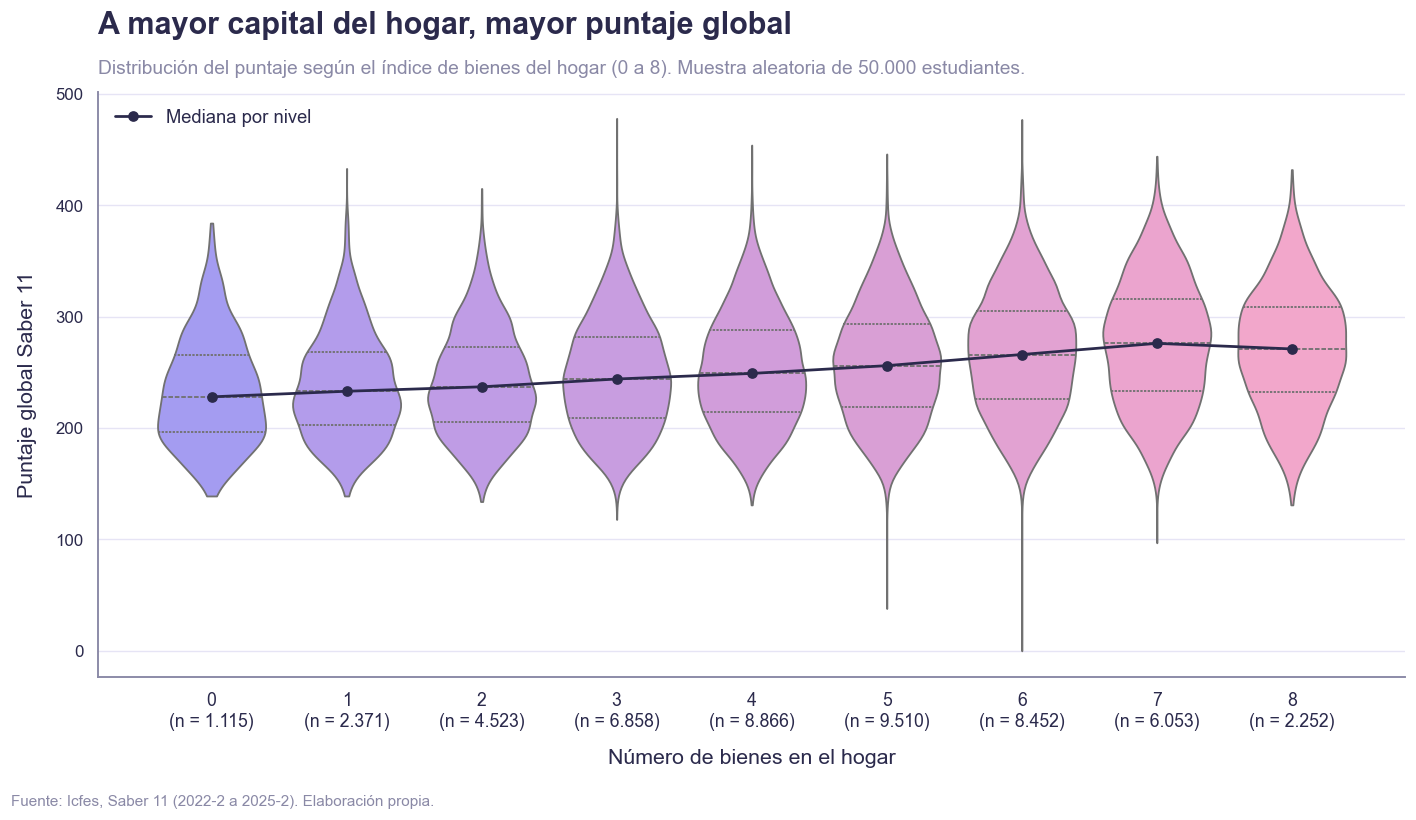

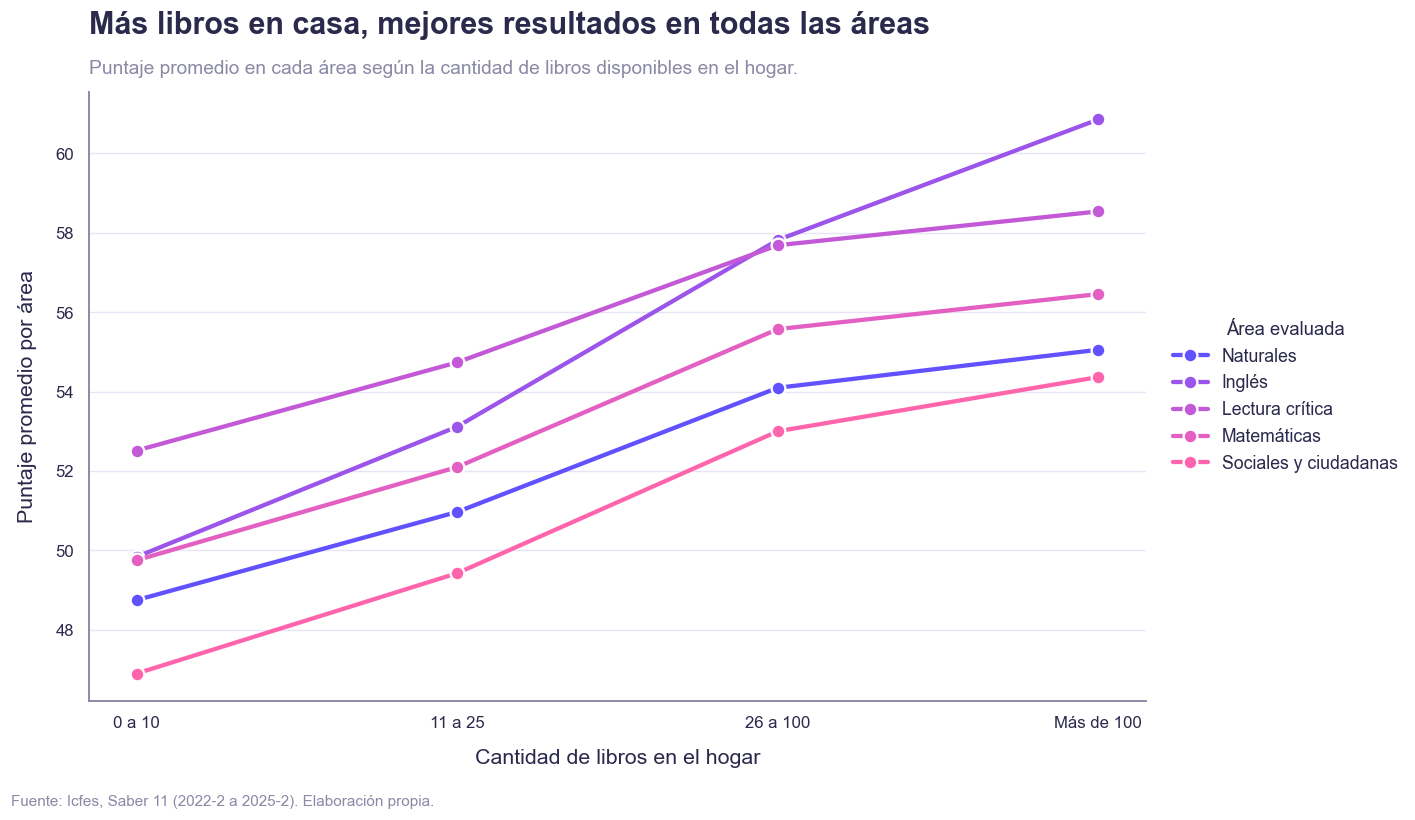

Mediana y tamaño por índice de bienes:
                   n  mediana  promedio
indice_bienes                          
0               3807    230.0    235.86
1               8228    232.0    237.38
2              15380    237.0    240.90
3              23118    243.0    246.87
4              29764    249.0    251.59
5              32094    257.0    257.61
6              28589    266.0    266.66
7              20149    276.0    276.17
8               7875    272.0    271.24


In [51]:

bienes_hogar = {
    "fami_tieneautomovil": "Automóvil",
    "fami_tienecomputador": "Computador",
    "fami_tieneconsolavideojuegos": "Consola de videojuegos",
    "fami_tienehornomicroogas": "Horno o microondas",
    "fami_tieneinternet": "Internet",
    "fami_tienelavadora": "Lavadora",
    "fami_tienemotocicleta": "Motocicleta",
    "fami_tieneserviciotv": "Servicio de televisión",
}

nombres_area = {
    "punt_c_naturales": "Naturales",
    "punt_ingles": "Inglés",
    "punt_lectura_critica": "Lectura crítica",
    "punt_matematicas": "Matemáticas",
    "punt_sociales_ciudadanas": "Sociales y ciudadanas",
}

PALETA = ["#6251ff", "#7d52f7", "#9254ef", "#a455e6", "#b457de", "#c359d6",
          "#d05bce", "#dd5dc6", "#e960be", "#f462b5", "#ff65ad"]
TEXTO = "#2b2a4c"
GRIS = "#8a89a6"
REJILLA = "#e6e4f5"

fuente = "Fuente: Icfes, Saber 11 (2022-2 a 2025-2). Elaboración propia."

cmap_ponencia = LinearSegmentedColormap.from_list("ponencia", PALETA)

def colores(n, suavizar=0.0):
    """n colores equidistantes de la gama. 'suavizar' (0 a 1) los mezcla con blanco -> tono pastel."""
    lista = []
    for x in np.linspace(0, 1, n):
        rgb = np.array(to_rgb(cmap_ponencia(x)))
        lista.append(tuple(rgb + (1 - rgb) * suavizar))
    return lista

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "text.color": TEXTO,
    "axes.labelcolor": TEXTO,
    "axes.edgecolor": GRIS,
    "xtick.color": TEXTO,
    "ytick.color": TEXTO,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": REJILLA,
    "grid.linewidth": 0.9,
})

def titulo(ax, principal, subtitulo):
    ax.set_title(principal, loc="left", fontsize=20, fontweight="bold", pad=38)
    ax.text(0, 1.03, subtitulo, transform=ax.transAxes, fontsize=12.5, color=GRIS)

def miles(v):
    return f"{v:,}".replace(",", ".")


# 2. Figura 1: bienes del hogar vs. puntaje global
bienes_disponibles = [variable for variable in bienes_hogar if variable in df.columns]
df["indice_bienes"] = df[bienes_disponibles].eq("si").sum(axis=1)

datos_bienes = df[["indice_bienes", objetivo]].dropna()
muestra_bienes = datos_bienes.sample(min(50000, len(datos_bienes)), random_state=42)

n_por_nivel = muestra_bienes["indice_bienes"].value_counts().sort_index()
niveles = list(n_por_nivel.index)
paleta_bienes = dict(zip(niveles, colores(len(niveles), suavizar=0.35)))
medianas = muestra_bienes.groupby("indice_bienes")[objetivo].median().reindex(niveles)

fig1, ax1 = plt.subplots(figsize=(13, 7.5))
sns.violinplot(
    data=muestra_bienes, x="indice_bienes", y=objetivo,
    hue="indice_bienes", order=niveles, hue_order=niveles,
    palette=paleta_bienes, inner="quartile", cut=0, linewidth=1.2,
    legend=False, ax=ax1,
)
ax1.plot(range(len(niveles)), medianas.values, color=TEXTO, marker="o",
         markersize=6, linewidth=1.8, zorder=5, label="Mediana por nivel")

ax1.set_xticks(range(len(niveles)))
ax1.set_xticklabels([f"{k}\n(n = {miles(n_por_nivel[k])})" for k in niveles], fontsize=11.5)
ax1.set_xlabel("Número de bienes en el hogar", fontsize=14, labelpad=12)
ax1.set_ylabel("Puntaje global Saber 11", fontsize=14, labelpad=12)
ax1.grid(axis="x", visible=False)
ax1.legend(frameon=False, loc="upper left", fontsize=12)

titulo(ax1,
       "A mayor capital del hogar, mayor puntaje global",
       f"Distribución del puntaje según el índice de bienes del hogar (0 a {len(bienes_disponibles)}). "
       f"Muestra aleatoria de {miles(len(muestra_bienes))} estudiantes.")
fig1.text(0.01, 0.01, fuente, fontsize=10, color=GRIS)
fig1.tight_layout(rect=[0, 0.03, 1, 1])
# fig1.savefig("fig1_bienes_puntaje.png", dpi=300, bbox_inches="tight")
plt.show()


# 3. Figura 2: libros en el hogar vs. promedio por área

etiquetas_libros = {
    "0a10libros": "0 a 10",
    "11a25libros": "11 a 25",
    "26a100libros": "26 a 100",
    "masde100libros": "Más de 100",
}
orden_libros = [c for c in etiquetas_libros if c in df["fami_numlibros"].dropna().unique()]

libros_area = (
    df.groupby("fami_numlibros")[areas].mean()
      .rename(columns=nombres_area)
      .reindex(orden_libros)
)
libros_area.index = [etiquetas_libros[c] for c in libros_area.index]

fig2, ax2 = plt.subplots(figsize=(13, 7.5))
for columna, color in zip(libros_area.columns, colores(len(libros_area.columns))):
    ax2.plot(libros_area.index, libros_area[columna], color=color, marker="o",
             markersize=9, linewidth=2.8, markeredgecolor="white",
             markeredgewidth=1.5, label=columna)

ax2.set_xlabel("Cantidad de libros en el hogar", fontsize=14, labelpad=12)
ax2.set_ylabel("Puntaje promedio por área", fontsize=14, labelpad=12)
ax2.grid(axis="x", visible=False)
ax2.legend(title="Área evaluada", title_fontsize=12, fontsize=11.5, frameon=False,
           loc="center left", bbox_to_anchor=(1.01, 0.5))

titulo(ax2,
       "Más libros en casa, mejores resultados en todas las áreas",
       "Puntaje promedio en cada área según la cantidad de libros disponibles en el hogar.")
fig2.text(0.01, 0.01, fuente, fontsize=10, color=GRIS)
fig2.tight_layout(rect=[0, 0.03, 1, 1])
# fig2.savefig("fig2_libros_areas.png", dpi=300, bbox_inches="tight")
plt.show()


# 4. Tabla de apoyo
print("Mediana y tamaño por índice de bienes:")
print(df.groupby("indice_bienes")[objetivo].agg(n="size", mediana="median", promedio="mean").round(2))

En la figura de tenencia de bienes se evidencia como entre más objetos el estudiante tenga en casa, la media del puntaje entre los grupos tiende a crecer. Se relaciona tenencia de bienes con nivel adquisitivo de la persona.

En la figura de la cantidad de libros en el hogar se puede ver la tendencia de crecimiento, entre más libro mayor el puntaje en los diferentes componentes de la prueba

## Matemáticas y Lectura crítica según el colegio y el territorio

Cada figura se presenta por separado para facilitar la lectura. Las cajas y violines comparan la distribución completa de Matemáticas y Ciencias naturales, no solamente el promedio. Para municipios se muestran las categorías con mayor cantidad de estudiantes y se conserva el tamaño muestral.

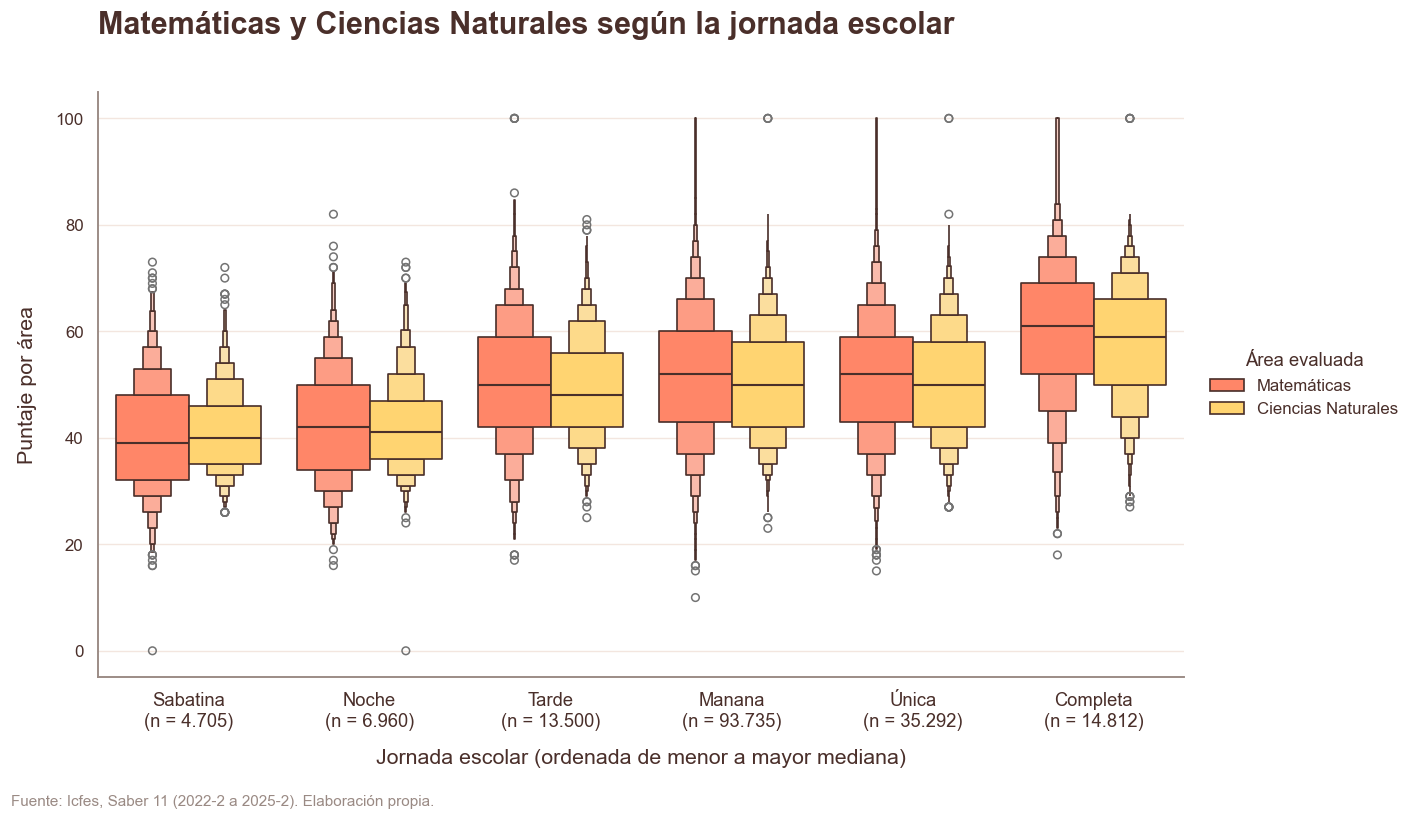

Medianas por jornada:


n  mediana  promedio
cole_jornada Área                                        
Completa     Ciencias Naturales  14812     60.0     58.53
             Matemáticas         14812     62.0     60.57
Manana       Ciencias Naturales  93735     50.0     50.40
             Matemáticas         93735     52.0     51.55
Noche        Ciencias Naturales   6960     41.0     41.94
             Matemáticas          6960     41.0     41.66
Sabatina     Ciencias Naturales   4705     40.0     41.15
             Matemáticas          4705     40.0     40.37
Tarde        Ciencias Naturales  13500     48.0     49.24
             Matemáticas         13500     50.0     50.28
Única        Ciencias Naturales  35292     50.0     50.34
             Matemáticas         35292     52.0     51.56

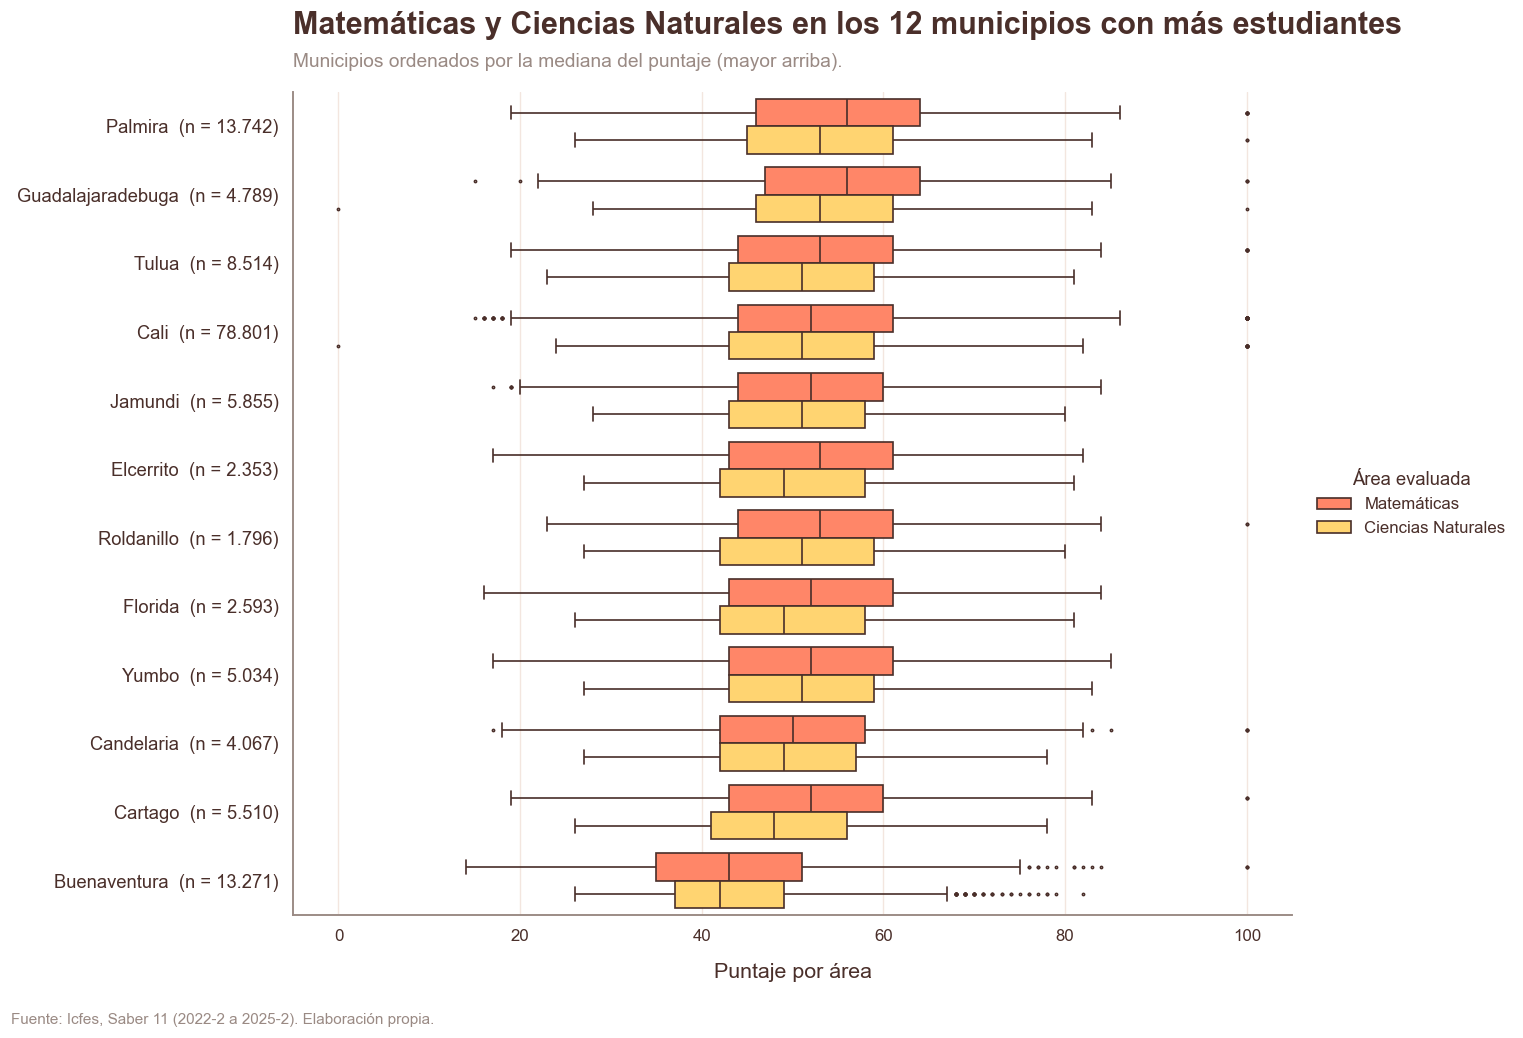

Municipios incluidos: los 12 con mayor número de estudiantes


n  mediana  promedio
cole_mcpio_ubicacion Área                                        
Buenaventura         Ciencias Naturales  13271     42.0     43.59
                     Matemáticas         13271     43.0     43.88
Cali                 Ciencias Naturales  78801     51.0     51.33
                     Matemáticas         78801     53.0     52.37
Candelaria           Ciencias Naturales   4067     49.0     49.55
                     Matemáticas          4067     51.0     50.43
Cartago              Ciencias Naturales   5510     48.0     49.20
                     Matemáticas          5510     52.0     51.19
Elcerrito            Ciencias Naturales   2353     50.0     50.56
                     Matemáticas          2353     52.0     51.43
Florida              Ciencias Naturales   2593     50.0     50.58
                     Matemáticas          2593     52.0     51.98
Guadalajaradebuga    Ciencias Naturales   4789     53.0     53.08
                     Matemáticas          4789     55.0     54.99
Jamundi              Ciencias Naturales   5855     51.0     51.02
                     Matemáticas          5855     52.0     52.16
Palmira              Ciencias Naturales  13742     53.0     53.08
                     Matemáticas         13742     55.0     54.67
Roldanillo           Ciencias Naturales   1796     50.0     50.78
                     Matemáticas          1796     53.0     52.53
Tulua                Ciencias Naturales   8514     51.0     51.53
                     Matemáticas          8514     54.0     53.22
Yumbo                Ciencias Naturales   5034     50.0     50.80
                     Matemáticas          5034     52.0     51.73

In [52]:

PALETA_CALIDA = ["#ff5e36", "#ff713c", "#ff8241", "#ff9247", "#ffa24e", "#ffb154",
                 "#ffc05a", "#ffcf61", "#ffdd67", "#ffec6e", "#fffa75"]
TXT = "#4a2f2a"    # marrón oscuro cálido: títulos, ejes y contornos
GRS = "#9a8a84"    # subtítulos y notas
GRD = "#f3e6df"    # rejilla suave

fuente = "Fuente: Icfes, Saber 11 (2022-2 a 2025-2). Elaboración propia."

def aclarar(hex_color, f=0.0):
    """Mezcla el color con blanco (f entre 0 y 1) para lograr un tono pastel."""
    rgb = np.array(to_rgb(hex_color))
    return tuple(rgb + (1 - rgb) * f)

def miles(v):
    return f"{int(v):,}".replace(",", ".")

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "text.color": TXT,
    "axes.labelcolor": TXT,
    "axes.edgecolor": GRS,
    "xtick.color": TXT,
    "ytick.color": TXT,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRD,
    "grid.linewidth": 0.9,
})

def titulo_c(ax, principal, subtitulo):
    ax.set_title(principal, loc="left", fontsize=20, fontweight="bold", pad=38)
    ax.text(0, 1.03, subtitulo, transform=ax.transAxes, fontsize=12.5, color=GRS)

# Etiquetas de área corregidas: ahora coinciden con los títulos
areas_colegio = {
    "punt_matematicas": "Matemáticas",
    "punt_c_naturales": "Ciencias Naturales",
}
orden_areas = list(areas_colegio.values())

# Dos tonos bien separados de la gama: el extremo coral y el amarillo cálido
colores_area = {
    "Matemáticas": aclarar(PALETA_CALIDA[0], 0.25),
    "Ciencias Naturales": aclarar(PALETA_CALIDA[7], 0.10),
}

def a_formato_largo(columna, filtro=None):
    """Devuelve (tabla larga Área/Puntaje, n de estudiantes por categoría) con etiquetas limpias."""
    base = df[[columna, *areas_colegio]].dropna(subset=[columna]).copy()
    if filtro is not None:
        base = base[base[columna].isin(filtro)]
    base[columna] = base[columna].astype(str).str.strip().str.title().replace({"Unica": "Única"})
    n_estudiantes = base[columna].value_counts()
    largo = base.melt(id_vars=columna, var_name="Área", value_name="Puntaje").dropna(subset=["Puntaje"])
    largo["Área"] = largo["Área"].map(areas_colegio)
    return largo, n_estudiantes

def etiquetas_con_n(orden, n_estudiantes, salto="\n"):
    return [f"{c}{salto}(n = {miles(n_estudiantes[c])})" for c in orden]

# 3. Figura: jornada escolar

jornada, n_jornada = a_formato_largo("cole_jornada")
orden_jornada = jornada.groupby("cole_jornada")["Puntaje"].median().sort_values().index
muestra_jornada = jornada.sample(min(60000, len(jornada)), random_state=42)

fig_jor, ax = plt.subplots(figsize=(13, 7.5))
sns.boxenplot(data=muestra_jornada, x="cole_jornada", y="Puntaje", hue="Área",
              order=orden_jornada, hue_order=orden_areas, palette=colores_area,
              saturation=1, linewidth=1.1, linecolor=TXT, ax=ax)
ax.set_xticks(range(len(orden_jornada)))
ax.set_xticklabels(etiquetas_con_n(orden_jornada, n_jornada), fontsize=12)
ax.set_xlabel("Jornada escolar (ordenada de menor a mayor mediana)", fontsize=14, labelpad=12)
ax.set_ylabel("Puntaje por área", fontsize=14, labelpad=12)
ax.grid(axis="x", visible=False)
sns.move_legend(ax, "center left", bbox_to_anchor=(1.01, 0.5), title="Área evaluada", frameon=False)
titulo_c(ax, "Matemáticas y Ciencias Naturales según la jornada escolar", "")
fig_jor.text(0.01, 0.01, fuente, fontsize=10, color=GRS)
fig_jor.tight_layout(rect=[0, 0.03, 1, 1])
# fig_jor.savefig("fig_colegio_jornada.png", dpi=300, bbox_inches="tight")
plt.show()

print("Medianas por jornada:")
display(jornada.groupby(["cole_jornada", "Área"])["Puntaje"].agg(n="size", mediana="median", promedio="mean").round(2))


# 4. Figura: municipio del colegio (12 con más estudiantes)

municipios_colegio = df["cole_mcpio_ubicacion"].value_counts().head(12).index
municipio_colegio, n_municipio = a_formato_largo("cole_mcpio_ubicacion", filtro=municipios_colegio)
# Mayor mediana arriba: en un eje Y horizontal, el primer elemento queda en la parte superior
orden_municipio = municipio_colegio.groupby("cole_mcpio_ubicacion")["Puntaje"].median().sort_values(ascending=False).index
muestra_municipio = municipio_colegio.sample(min(70000, len(municipio_colegio)), random_state=42)

fig_mun, ax = plt.subplots(figsize=(14, 9.5))
sns.boxplot(data=muestra_municipio, x="Puntaje", y="cole_mcpio_ubicacion", hue="Área",
            order=orden_municipio, hue_order=orden_areas, palette=colores_area,
            saturation=1, linewidth=1.1, linecolor=TXT, fliersize=1.5, ax=ax)
ax.set_yticks(range(len(orden_municipio)))
ax.set_yticklabels(etiquetas_con_n(orden_municipio, n_municipio, salto="  "), fontsize=12)
ax.set_xlabel("Puntaje por área", fontsize=14, labelpad=12)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
sns.move_legend(ax, "center left", bbox_to_anchor=(1.01, 0.5), title="Área evaluada", frameon=False)
titulo_c(ax, "Matemáticas y Ciencias Naturales en los 12 municipios con más estudiantes",
         "Municipios ordenados por la mediana del puntaje (mayor arriba). ")
fig_mun.text(0.01, 0.01, fuente, fontsize=10, color=GRS)
fig_mun.tight_layout(rect=[0, 0.03, 1, 1])
# fig_mun.savefig("fig_colegio_municipio.png", dpi=300, bbox_inches="tight")
plt.show()

print("Municipios incluidos: los 12 con mayor número de estudiantes")
display(municipio_colegio.groupby(["cole_mcpio_ubicacion", "Área"])["Puntaje"].agg(n="size", mediana="median", promedio="mean").round(2))


Según la literatura consultada el puntaje de matemáticas y ciencias naturales se relaciona de gran forma con el punaje saber. Al hacer un análsisis entre las jornadas de colegio, se puede ver dicha diferencia. Siendo la jornada completa con mayor media entre las demás.

Ver la distribución del puntaje por las ciudades con mayor población estudiantil que presenta la preuba.

Palmira logró el mejor puntaje saber 11 en 2025-2, según el gráfico obtuvo mejor puntaje en matemáticas y ciencias naturales, lo que se relaciona con la literatura leída que el puntaje de estas dos materias están altamente relacionadas para que el puntaje sea mayor

# Distribución de Puntaje por Perido Académico

El objetivo es identificar la tendencia entre estos dos periodos. Teniendo en cuenta que los periodos 1 de las pruebas saber 11 están relacionados con los colegios de calendario B (normalmente no oficiales) y los peridos 2 con calendario A. ¿Existe cambios entre periodos?

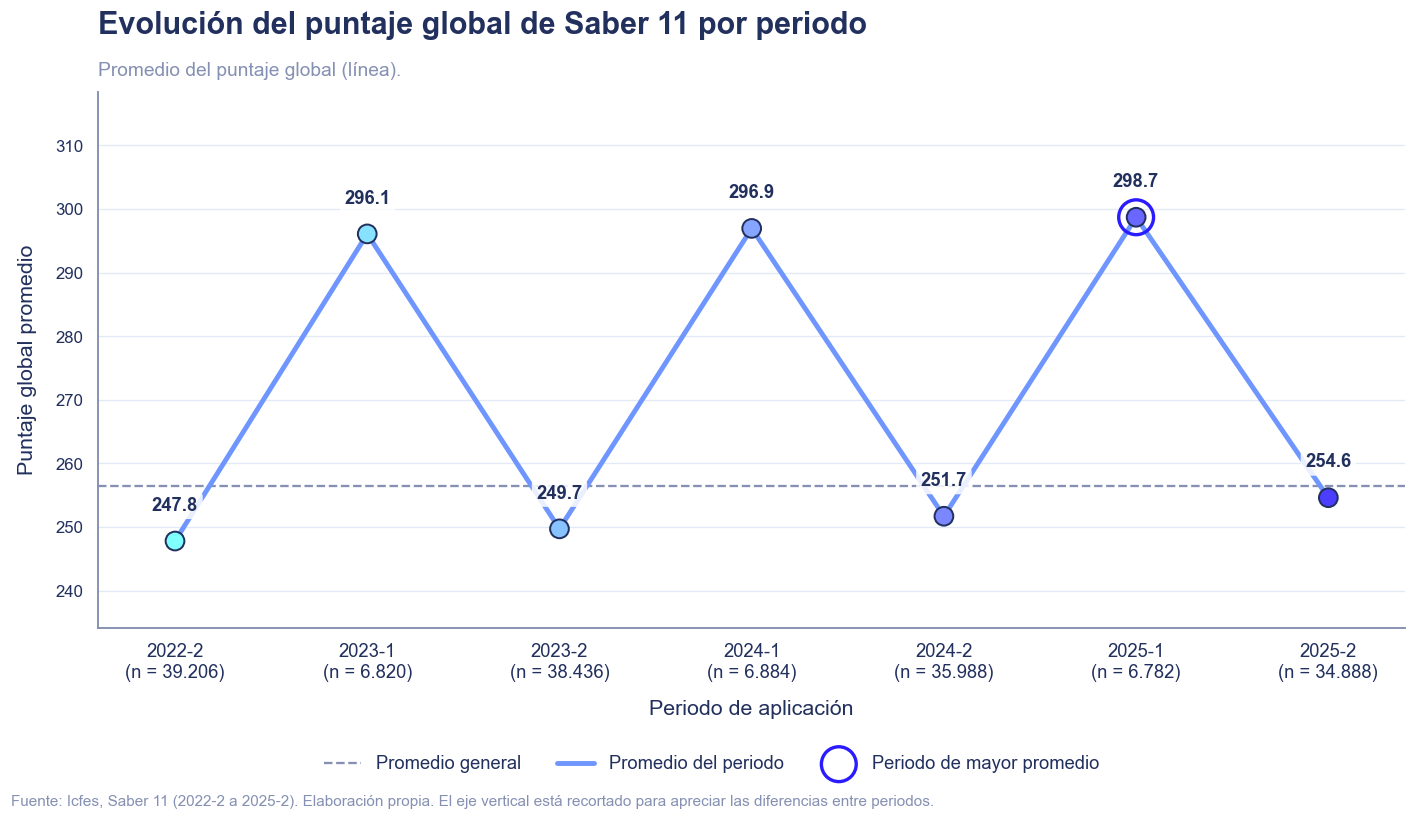

Resumen estadístico por periodo:


,n,promedio,mediana,desviacion,ic95_inf,ic95_sup
periodo,,,,,,
20222,39206,247.80,245.0,49.16,247.31,248.29
20231,6820,296.09,300.0,52.26,294.85,297.33
20232,38436,249.72,247.0,48.58,249.23,250.20
20241,6884,296.95,301.0,53.12,295.69,298.20
20242,35988,251.70,249.0,50.38,251.18,252.22
20251,6782,298.70,303.0,54.23,297.41,299.99
20252,34888,254.61,252.0,51.46,254.07,255.15


In [ ]:
# Comparación temporal del puntaje global por periodo

PALETA_FRIA = ["#69ffff", "#70eaff", "#73d5ff", "#74c0ff", "#73abff", "#6f96ff",
               "#6981ff", "#606bff", "#5555ff", "#443cff", "#2b1cff"]
TXT_F = "#22305e"   # azul marino: títulos, ejes y contornos
GRS_F = "#8590b3"   # subtítulos y notas
GRD_F = "#e3eaf7"   # rejilla suave

fuente = ("Fuente: Icfes, Saber 11 (2022-2 a 2025-2). Elaboración propia. "
          "El eje vertical está recortado para apreciar las diferencias entre periodos.")

cmap_fria = LinearSegmentedColormap.from_list("fria", PALETA_FRIA)

def colores_frios(n, suavizar=0.0):
    """n colores equidistantes de la gama; 'suavizar' los mezcla con blanco (tono pastel)."""
    lista = []
    for v in np.linspace(0, 1, n):
        rgb = np.array(to_rgb(cmap_fria(v)))
        lista.append(tuple(rgb + (1 - rgb) * suavizar))
    return lista

def miles(v):
    return f"{int(v):,}".replace(",", ".")

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "text.color": TXT_F,
    "axes.labelcolor": TXT_F,
    "axes.edgecolor": GRS_F,
    "xtick.color": TXT_F,
    "ytick.color": TXT_F,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRD_F,
    "grid.linewidth": 0.9,
})

def titulo_f(ax, principal, subtitulo):
    ax.set_title(principal, loc="left", fontsize=20, fontweight="bold", pad=38)
    ax.text(0, 1.03, subtitulo, transform=ax.transAxes, fontsize=12.5, color=GRS_F)

# 2. Resumen por periodo
periodos = (
    df.groupby("periodo")["punt_global"]
    .agg(n="size", promedio="mean", mediana="median", desviacion="std")
    .sort_index()
)
periodos["etiqueta"] = periodos.index.astype(str).str[:4] + "-" + periodos.index.astype(str).str[-1]
periodos["error_estandar"] = periodos["desviacion"] / np.sqrt(periodos["n"])
periodos["ic95_inf"] = periodos["promedio"] - 1.96 * periodos["error_estandar"]
periodos["ic95_sup"] = periodos["promedio"] + 1.96 * periodos["error_estandar"]

x = np.arange(len(periodos))
y = periodos["promedio"].to_numpy()
promedio_general = (periodos["promedio"] * periodos["n"]).sum() / periodos["n"].sum()
idx_max = int(np.argmax(y))
colores_tiempo = colores_frios(len(periodos), suavizar=0.15)


# 3. Figura: evolución del puntaje global
fig_periodo, ax = plt.subplots(figsize=(13, 7.5))


# Referencia: promedio de todo el periodo analizado
ax.axhline(promedio_general, color=GRS_F, linestyle="--", linewidth=1.5,
           zorder=1, label="Promedio general")

# Línea y puntos (el color de los puntos avanza con el tiempo: de cian a azul)
ax.plot(x, y, color=PALETA_FRIA[5], linewidth=3.2, zorder=3, label="Promedio del periodo")
ax.scatter(x, y, s=150, c=colores_tiempo, edgecolors=TXT_F, linewidths=1.3, zorder=5)

# Resalta el periodo con mayor promedio
ax.scatter(x[idx_max], y[idx_max], s=520, facecolors="none",
           edgecolors=PALETA_FRIA[-1], linewidths=2.2, zorder=4,
           label="Periodo de mayor promedio")

# Valor del promedio sobre cada punto
for xi, yi in zip(x, y):
    ax.annotate(f"{yi:.1f}", (xi, yi), textcoords="offset points", xytext=(0, 20),
                ha="center", fontsize=12, fontweight="bold", color=TXT_F, zorder=6,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85))

# Ejes
ax.set_xticks(x)
ax.set_xticklabels([f"{e}\n(n = {miles(n)})" for e, n in zip(periodos["etiqueta"], periodos["n"])],
                   fontsize=12)
ax.set_xlim(-0.4, len(x) - 0.6)
lo = periodos['ic95_inf'].min()
hi = periodos['ic95_sup'].max()
margen = max(hi - lo, 1) * 0.25
ax.set_ylim(lo - margen, hi + margen * 1.4)
ax.set_xlabel("Periodo de aplicación", fontsize=14, labelpad=12)
ax.set_ylabel("Puntaje global promedio", fontsize=14, labelpad=12)
ax.grid(axis="x", visible=False)

titulo_f(ax, "Evolución del puntaje global de Saber 11 por periodo",
         "Promedio del puntaje global (línea).")

handles, etiquetas = ax.get_legend_handles_labels()
fig_periodo.legend(handles, etiquetas, loc="lower center", bbox_to_anchor=(0.5, 0.03),
                   ncol=4, frameon=False, fontsize=12)
fig_periodo.text(0.01, 0.01, fuente, fontsize=10, color=GRS_F)
fig_periodo.tight_layout(rect=[0, 0.09, 1, 1])
# fig_periodo.savefig("fig_evolucion_periodo.png", dpi=300, bbox_inches="tight")
plt.show()

print("Resumen estadístico por periodo:")
display(periodos[["n", "promedio", "mediana", "desviacion", "ic95_inf", "ic95_sup"]].round(2))

## Hábitos alimenticios, condiciones del hogar 
La figura compara en una misma escala el puntaje de `punt_c_naturales` según la frecuencia de consumo de alimentos y el número de cuartos del hogar. 

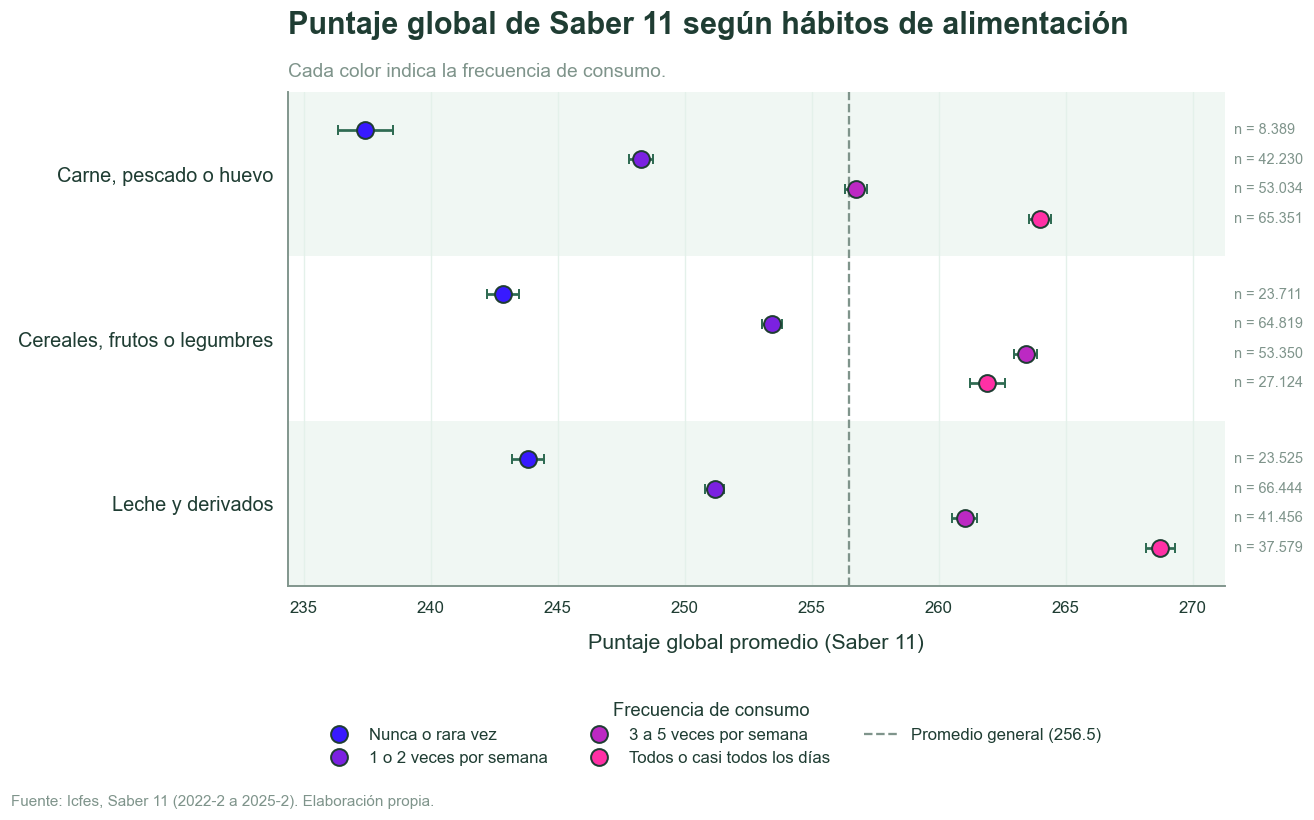

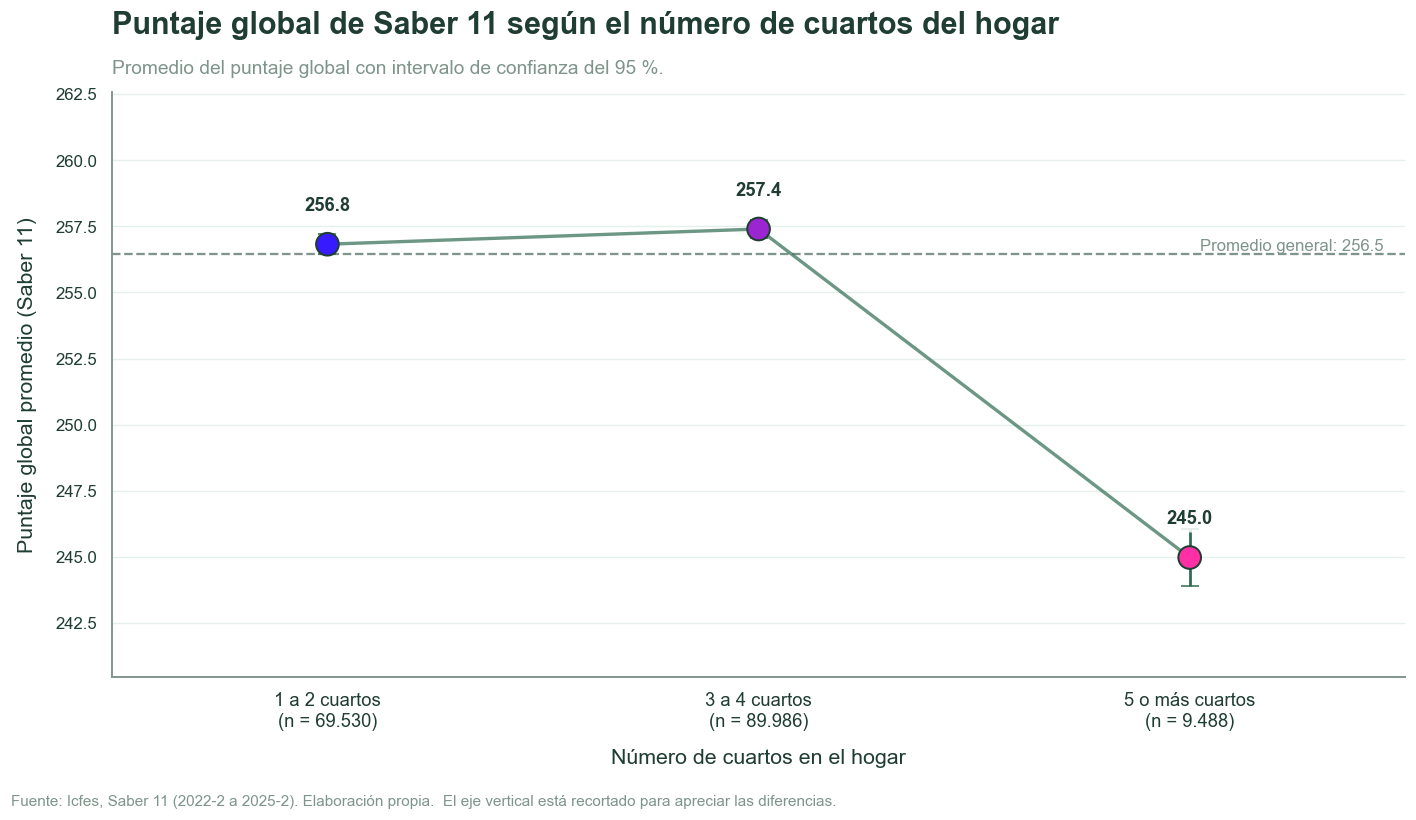

Resumen por hábito alimenticio:


,variable,categoria,n,promedio,ic95
0,"Carne, pescado o huevo",Nunca o rara vez,8389,237.42,1.07
1,"Carne, pescado o huevo",1 o 2 veces por semana,42230,248.29,0.47
2,"Carne, pescado o huevo",3 a 5 veces por semana,53034,256.72,0.43
3,"Carne, pescado o huevo",Todos o casi todos los días,65351,263.99,0.42
4,"Cereales, frutos o legumbres",Nunca o rara vez,23711,242.85,0.62
5,"Cereales, frutos o legumbres",1 o 2 veces por semana,64819,253.44,0.39
6,"Cereales, frutos o legumbres",3 a 5 veces por semana,53350,263.42,0.45
7,"Cereales, frutos o legumbres",Todos o casi todos los días,27124,261.91,0.68
8,Leche y derivados,Nunca o rara vez,23525,243.82,0.64
9,Leche y derivados,1 o 2 veces por semana,66444,251.17,0.38


Resumen por cuartos del hogar:


,n,promedio,ic95
categoria,,,
1 a 2 cuartos,69530,256.82,0.38
3 a 4 cuartos,89986,257.40,0.35
5 o más cuartos,9488,244.98,1.07


In [54]:

#
# 1. Paleta, estilo y utilidades
#
PALETA_VERDE = ["#2200ff", "#6c08de", "#b511bc", "#ff199b"]
TXT_V = "#1f3d33"     # verde muy oscuro: títulos, ejes y contornos
TRAZO_V = "#2f6b52"   # verde medio-oscuro: barras de error y líneas
GRS_V = "#7f948b"     # subtítulos y notas
GRD_V = "#e4f1ea"     # rejilla y franjas suaves

fuente = ("Fuente: Icfes, Saber 11 (2022-2 a 2025-2). Elaboración propia. ")

cmap_verde = LinearSegmentedColormap.from_list("verde", PALETA_VERDE)

def colores_verdes(n, suavizar=0.0):
    """n colores equidistantes de la gama; 'suavizar' los mezcla con blanco (tono pastel)."""
    lista = []
    for v in np.linspace(0, 1, n):
        rgb = np.array(to_rgb(cmap_verde(v)))
        lista.append(tuple(rgb + (1 - rgb) * suavizar))
    return lista

def miles(v):
    return f"{int(v):,}".replace(",", ".")

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "text.color": TXT_V,
    "axes.labelcolor": TXT_V,
    "axes.edgecolor": GRS_V,
    "xtick.color": TXT_V,
    "ytick.color": TXT_V,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRD_V,
    "grid.linewidth": 0.9,
})

def titulo_v(ax, principal, subtitulo):
    ax.set_title(principal, loc="left", fontsize=20, fontweight="bold", pad=38)
    ax.text(0, 1.03, subtitulo, transform=ax.transAxes, fontsize=12.5, color=GRS_V)

#
# 2. Agrupación de categorías y resumen estadístico
OBJETIVO = "punt_global"

# Alimentación: 4 niveles de frecuencia, comunes a los tres alimentos
niveles_consumo = ["Nunca o rara vez", "1 o 2 veces por semana",
                   "3 a 5 veces por semana", "Todos o casi todos los días"]
codigos_consumo = {
    "nuncaoraravezcomemoseso": niveles_consumo[0],
    "1o2vecesporsemana": niveles_consumo[1],
    "3a5vecesporsemana": niveles_consumo[2],
    "todosocasitodoslosdias": niveles_consumo[3],
}
variables_alimentacion = {
    "fami_comecarnepescadohuevo": "Carne, pescado o huevo",
    "fami_comecerealfrutoslegumbre": "Cereales, frutos o legumbres",
    "fami_comelechederivados": "Leche y derivados",
}

# Cuartos del hogar: 6+ categorías englobadas en 3 grupos (edita este diccionario si prefieres otro corte)
niveles_cuartos = ["1 a 2 cuartos", "3 a 4 cuartos", "5 o más cuartos"]
codigos_cuartos = {
    "uno": niveles_cuartos[0], "dos": niveles_cuartos[0],
    "tres": niveles_cuartos[1], "cuatro": niveles_cuartos[1],
    "cinco": niveles_cuartos[2], "seis": niveles_cuartos[2],
    "seisomas": niveles_cuartos[2], "masde6": niveles_cuartos[2],
}

def resumen_categoria(variable, mapa_categorias, orden_niveles):
    """n, promedio, desviación e IC 95 % del puntaje global por categoría (ya agrupada)."""
    datos = df[[variable, OBJETIVO]].dropna().copy()
    sin_mapa = sorted(set(datos[variable].unique()) - set(mapa_categorias))
    if sin_mapa:
        print(f"Aviso ({variable}): categorías sin agrupar, excluidas del gráfico -> {sin_mapa}")
    datos["categoria"] = datos[variable].map(mapa_categorias)
    resumen = (
        datos.dropna(subset=["categoria"])
        .groupby("categoria")[OBJETIVO]
        .agg(n="size", promedio="mean", desviacion="std")
    )
    resumen["ic95"] = 1.96 * resumen["desviacion"] / np.sqrt(resumen["n"])   # el 1.96 se aplica una sola vez
    return resumen.reindex([c for c in orden_niveles if c in resumen.index])

filas = []
for variable, nombre in variables_alimentacion.items():
    r = resumen_categoria(variable, codigos_consumo, niveles_consumo).reset_index()
    r.insert(0, "variable", nombre)
    filas.append(r)
resumen_alimentos = pd.concat(filas, ignore_index=True)
resumen_cuartos = resumen_categoria("fami_cuartoshogar", codigos_cuartos, niveles_cuartos)

promedio_general = df[OBJETIVO].mean()

# 3. Figura 1: hábitos alimenticios
nombres_filas = list(variables_alimentacion.values())
colores_consumo = dict(zip(niveles_consumo, colores_verdes(len(niveles_consumo), suavizar=0.10)))
desplazamiento = dict(zip(niveles_consumo, np.linspace(-0.27, 0.27, len(niveles_consumo))))

fig_alim, ax = plt.subplots(figsize=(13, 7.5))

# Franjas alternas para separar visualmente cada alimento
for i in range(len(nombres_filas)):
    if i % 2 == 0:
        ax.axhspan(i - 0.5, i + 0.5, color=GRD_V, alpha=0.55, linewidth=0, zorder=0)

ax.axvline(promedio_general, color=GRS_V, linestyle="--", linewidth=1.5, zorder=1)

for _, fila in resumen_alimentos.iterrows():
    y_pos = nombres_filas.index(fila["variable"]) + desplazamiento[fila["categoria"]]
    ax.errorbar(fila["promedio"], y_pos, xerr=fila["ic95"], fmt="o",
                ecolor=TRAZO_V, elinewidth=1.8, capsize=3.5, markersize=11,
                markerfacecolor=colores_consumo[fila["categoria"]],
                markeredgecolor=TXT_V, markeredgewidth=1.3, zorder=4)
    ax.text(1.01, y_pos, f"n = {miles(fila['n'])}", transform=ax.get_yaxis_transform(),
            va="center", fontsize=9.5, color=GRS_V)

lim_inf = min((resumen_alimentos["promedio"] - resumen_alimentos["ic95"]).min(), promedio_general)
lim_sup = max((resumen_alimentos["promedio"] + resumen_alimentos["ic95"]).max(), promedio_general)
margen = (lim_sup - lim_inf) * 0.06
ax.set_xlim(lim_inf - margen, lim_sup + margen)
ax.set_ylim(len(nombres_filas) - 0.5, -0.5)   # el primer alimento queda arriba
ax.set_yticks(range(len(nombres_filas)))
ax.set_yticklabels(nombres_filas, fontsize=13)
ax.set_xlabel("Puntaje global promedio (Saber 11)", fontsize=14, labelpad=12)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)

titulo_v(ax, "Puntaje global de Saber 11 según hábitos de alimentación", "Cada color indica la frecuencia de consumo.")

manijas = [Line2D([0], [0], marker="o", linestyle="", markersize=11,
                  markerfacecolor=colores_consumo[nivel], markeredgecolor=TXT_V,
                  markeredgewidth=1.3, label=nivel) for nivel in niveles_consumo]
manijas.append(Line2D([0], [0], color=GRS_V, linestyle="--", linewidth=1.5,
                      label=f"Promedio general ({promedio_general:.1f})"))
fig_alim.legend(handles=manijas, loc="lower center", bbox_to_anchor=(0.5, 0.04), ncol=3,
                frameon=False, fontsize=11, title="Frecuencia de consumo", title_fontsize=12)
fig_alim.text(0.01, 0.01, fuente, fontsize=10, color=GRS_V)
fig_alim.tight_layout(rect=[0, 0.17, 0.93, 1])
# fig_alim.savefig("fig_alimentacion.png", dpi=300, bbox_inches="tight")
plt.show()

x = np.arange(len(resumen_cuartos))
y = resumen_cuartos["promedio"].to_numpy()

fig_cuartos, ax = plt.subplots(figsize=(13, 7.5))
ax.axhline(promedio_general, color=GRS_V, linestyle="--", linewidth=1.5, zorder=1)
ax.text(len(x) - 0.55, promedio_general, f"Promedio general: {promedio_general:.1f}",
        ha="right", va="bottom", fontsize=11, color=GRS_V)
ax.plot(x, y, color=TRAZO_V, linewidth=2.2, alpha=0.7, zorder=3)
ax.errorbar(x, y, yerr=resumen_cuartos["ic95"], fmt="none", ecolor=TRAZO_V,
            elinewidth=1.8, capsize=6, zorder=4)
ax.scatter(x, y, s=220, c=colores_verdes(len(x), suavizar=0.10),
           edgecolors=TXT_V, linewidths=1.3, zorder=5)
for xi, yi in zip(x, y):
    ax.annotate(f"{yi:.1f}", (xi, yi), textcoords="offset points", xytext=(0, 22),
                ha="center", fontsize=12, fontweight="bold", color=TXT_V, zorder=6,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85))

ax.set_xticks(x)
ax.set_xticklabels([f"{c}\n(n = {miles(n)})" for c, n in zip(resumen_cuartos.index, resumen_cuartos["n"])],
                   fontsize=12)
ax.set_xlim(-0.5, len(x) - 0.5)
lo = min((resumen_cuartos["promedio"] - resumen_cuartos["ic95"]).min(), promedio_general)
hi = max((resumen_cuartos["promedio"] + resumen_cuartos["ic95"]).max(), promedio_general)
margen = max(hi - lo, 1) * 0.25
ax.set_ylim(lo - margen, hi + margen * 1.4)
ax.set_xlabel("Número de cuartos en el hogar", fontsize=14, labelpad=12)
ax.set_ylabel("Puntaje global promedio (Saber 11)", fontsize=14, labelpad=12)
ax.grid(axis="x", visible=False)

titulo_v(ax, "Puntaje global de Saber 11 según el número de cuartos del hogar",
         "Promedio del puntaje global con intervalo de confianza del 95 %.")
fig_cuartos.text(0.01, 0.01, fuente + " El eje vertical está recortado para apreciar las diferencias.",
                 fontsize=10, color=GRS_V)
fig_cuartos.tight_layout(rect=[0, 0.03, 1, 1])
# fig_cuartos.savefig("fig_cuartos.png", dpi=300, bbox_inches="tight")
plt.show()

#
# 5. Tablas de apoyo
print("Resumen por hábito alimenticio:")
display(resumen_alimentos[["variable", "categoria", "n", "promedio", "ic95"]].round(2))
print("Resumen por cuartos del hogar:")
display(resumen_cuartos[["n", "promedio", "ic95"]].round(2))


Los habitos alimenticios de una persona también está ligado a la capacidad adquisitiva de la familia o del entorno del estudiante. Se puede ver que las personas que muy poco comen carne, huevos el promedio de estos estudiantes están por debajo de la media del puntaje global.

Al igual con la cantidad de habitaciones dentro de la casa. Familias extensas normalmente están relacionadas con familias de sectores populares donde existe poca planificación familiar y la desiguldad tiende a aumentar. (es un análisis parcial, ver otras aristas)

# Hábitos de estudio y conexión a internet

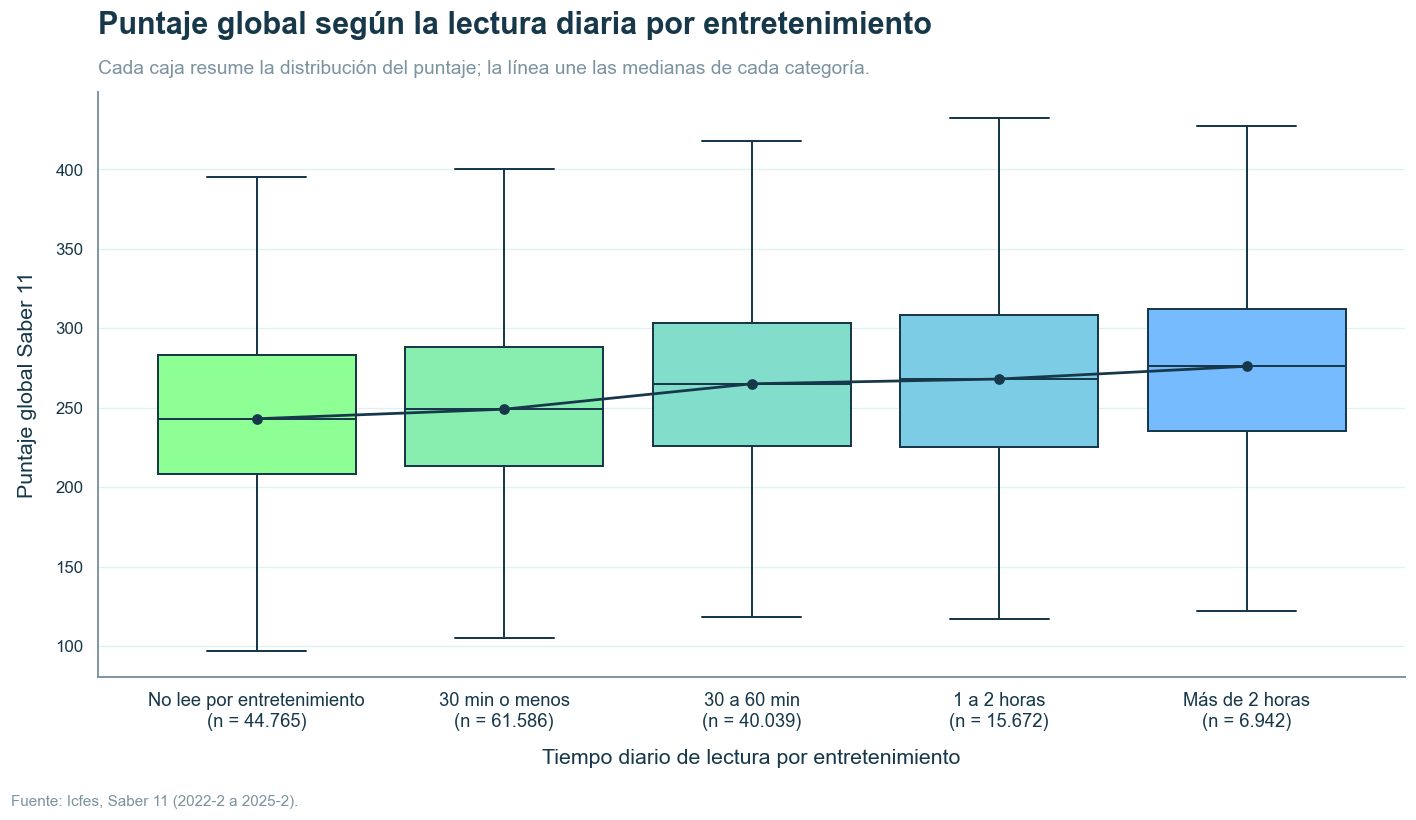

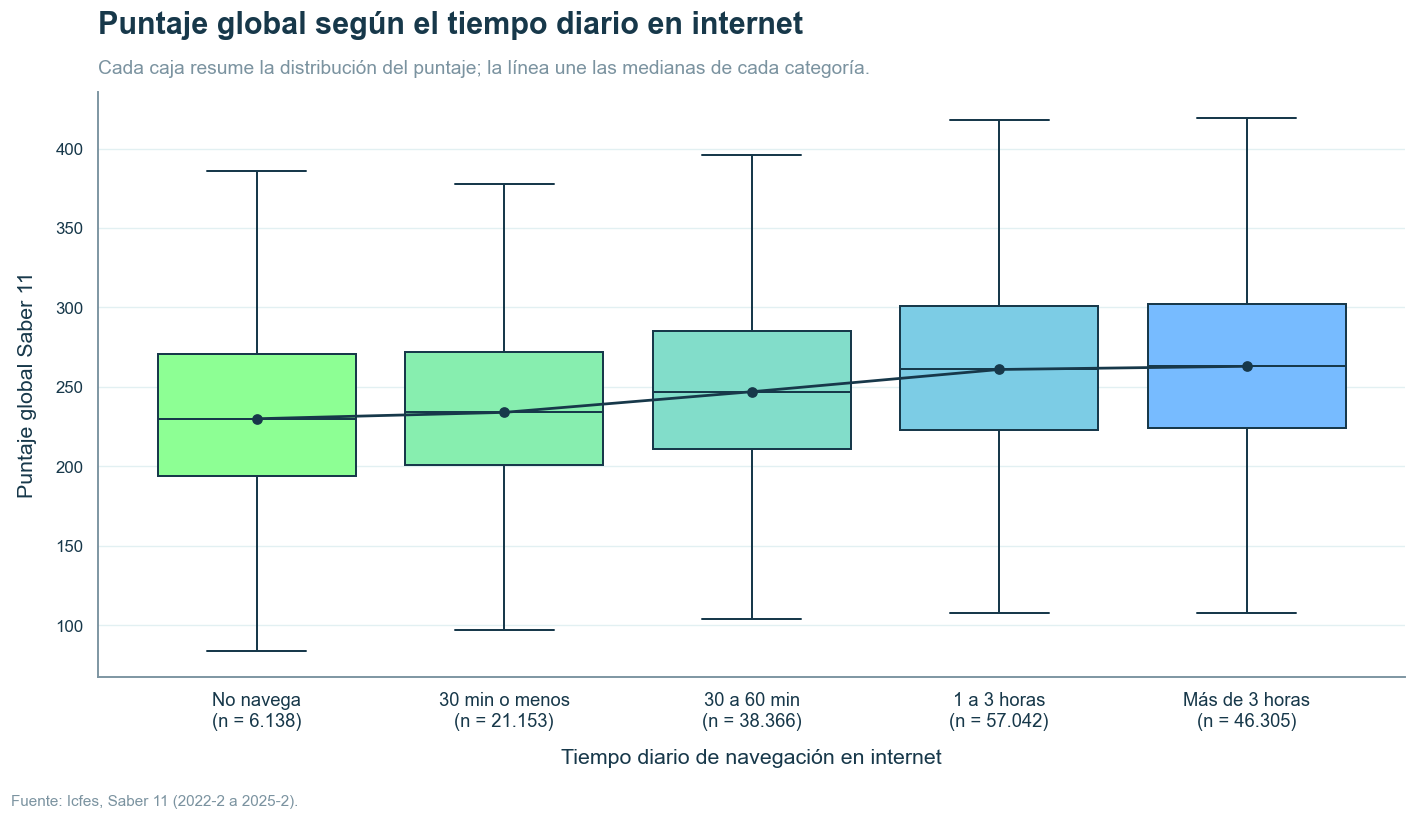

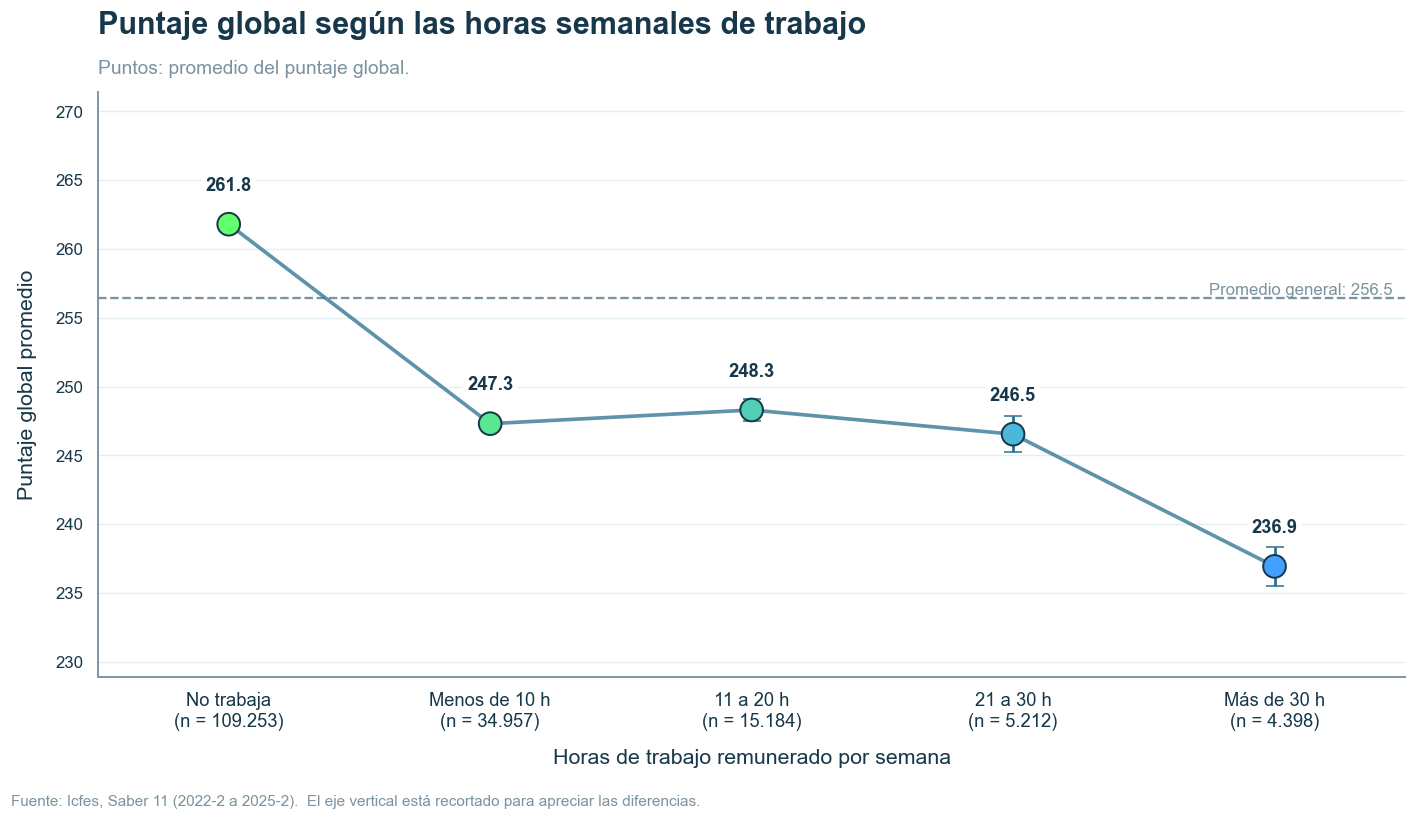

Resumen de lectura diaria:


,etiqueta,estudiantes,promedio,mediana
0,No lee por entretenimiento,44765,247.53,243.0
1,30 min o menos,61586,252.42,249.0
2,30 a 60 min,40039,265.71,265.0
3,1 a 2 horas,15672,267.13,268.0
4,Más de 2 horas,6942,272.62,276.0


Resumen de dedicación a internet:


,etiqueta,estudiantes,promedio,mediana
0,No navega,6138,235.28,230.0
1,30 min o menos,21153,239.29,234.0
2,30 a 60 min,38366,250.32,247.0
3,1 a 3 horas,57042,263.05,261.0
4,Más de 3 horas,46305,264.10,263.0


Resumen de trabajo semanal:


,etiqueta,estudiantes,promedio,mediana
0,No trabaja,109253,261.79,260.0
1,Menos de 10 h,34957,247.30,243.0
2,11 a 20 h,15184,248.30,246.0
3,21 a 30 h,5212,246.54,245.0
4,Más de 30 h,4398,236.93,233.0



Mayor promedio entre categorías de lectura: Más de 2 horas (272.62).
Mayor promedio entre categorías de internet: Más de 3 horas (264.10).
Mayor promedio entre categorías de trabajo: No trabaja (261.79).


In [62]:
PALETA_G = ["#4fff5b", "#48ea7c", "#41d59d", "#3bc0bd", "#34abde", "#2d96ff"]
TXT_G = "#17384a"     # azul petróleo oscuro: títulos, ejes y contornos
TRAZO_G = "#2a6f8f"   # azul medio-oscuro: líneas y barras de error
GRS_G = "#7b93a0"     # subtítulos y notas
GRD_G = "#e2f0f2"     # rejilla suave

fuente = "Fuente: Icfes, Saber 11 (2022-2 a 2025-2). "

cmap_g = LinearSegmentedColormap.from_list("verde_azul", PALETA_G)

def colores_g(n, suavizar=0.0):
    """n colores equidistantes de la gama; 'suavizar' los mezcla con blanco (tono pastel)."""
    lista = []
    for v in np.linspace(0, 1, n):
        rgb = np.array(to_rgb(cmap_g(v)))
        lista.append(tuple(rgb + (1 - rgb) * suavizar))
    return lista

def miles(v):
    return f"{int(v):,}".replace(",", ".")

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "text.color": TXT_G,
    "axes.labelcolor": TXT_G,
    "axes.edgecolor": GRS_G,
    "xtick.color": TXT_G,
    "ytick.color": TXT_G,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRD_G,
    "grid.linewidth": 0.9,
})

def titulo_g(ax, principal, subtitulo):
    ax.set_title(principal, loc="left", fontsize=20, fontweight="bold", pad=38)
    ax.text(0, 1.03, subtitulo, transform=ax.transAxes, fontsize=12.5, color=GRS_G)

# 2. Categorías (orden y etiquetas)
#
orden_lectura = ["noleoporentretenimiento", "30minutosomenos", "entre30y60minutos",
                 "entre1y2horas", "masde2horas"]
etiquetas_lectura = {
    "noleoporentretenimiento": "No lee por entretenimiento",
    "30minutosomenos": "30 min o menos",
    "entre30y60minutos": "30 a 60 min",
    "entre1y2horas": "1 a 2 horas",
    "masde2horas": "Más de 2 horas",
}

orden_internet = ["nonavegainternet", "30minutosomenos", "entre30y60minutos",
                  "entre1y3horas", "masde3horas"]
etiquetas_internet = {
    "nonavegainternet": "No navega",
    "30minutosomenos": "30 min o menos",
    "entre30y60minutos": "30 a 60 min",
    "entre1y3horas": "1 a 3 horas",
    "masde3horas": "Más de 3 horas",
}

orden_trabajo = ["0", "menosde10horas", "entre11y20horas", "entre21y30horas", "masde30horas"]
etiquetas_trabajo = {
    "0": "No trabaja",
    "menosde10horas": "Menos de 10 h",
    "entre11y20horas": "11 a 20 h",
    "entre21y30horas": "21 a 30 h",
    "masde30horas": "Más de 30 h",
}


# 3. Resumen por hábito
def resumen_habito(columna, orden, etiquetas):
    datos = df[[columna, objetivo]].dropna().copy()
    datos[columna] = datos[columna].astype(str)
    fuera_de_orden = sorted(set(datos[columna].unique()) - set(orden))
    if fuera_de_orden:
        print(f"Aviso ({columna}): categorías fuera del orden definido, excluidas del gráfico -> {fuera_de_orden}")
    datos = datos[datos[columna].isin(orden)].copy()
    datos["etiqueta"] = datos[columna].map(etiquetas)
    orden_etiquetas = [etiquetas[c] for c in orden if c in set(datos[columna])]
    resumen = (
        datos.groupby("etiqueta")[objetivo]
        .agg(estudiantes="size", promedio="mean", mediana="median", desviacion="std")
        .reindex(orden_etiquetas)
    )
    resumen["error"] = 1.96 * resumen["desviacion"] / np.sqrt(resumen["estudiantes"])
    return datos, resumen

lectura, resumen_lectura = resumen_habito("estu_dedicacionlecturadiaria", orden_lectura, etiquetas_lectura)
internet, resumen_internet = resumen_habito("estu_dedicacioninternet", orden_internet, etiquetas_internet)
trabajo, resumen_trabajo = resumen_habito("estu_horassemanatrabaja", orden_trabajo, etiquetas_trabajo)

# 4. Figuras 1 y 2: distribución del puntaje (cajas)

def figura_cajas(datos, resumen, xlabel, principal, subtitulo, archivo):
    categorias = list(resumen.index)
    colores = dict(zip(categorias, colores_g(len(categorias), suavizar=0.35)))

    fig, ax = plt.subplots(figsize=(13, 7.5))
    sns.boxplot(data=datos, x="etiqueta", y=objetivo, hue="etiqueta",
                order=categorias, hue_order=categorias, palette=colores,
                showfliers=False, linewidth=1.3, linecolor=TXT_G, saturation=1,
                legend=False, ax=ax)
    # Línea que une las medianas: hace visible la tendencia entre categorías
    ax.plot(range(len(categorias)), resumen["mediana"].to_numpy(), color=TXT_G,
            marker="o", markersize=6, linewidth=1.8, zorder=5)

    ax.set_xticks(range(len(categorias)))
    ax.set_xticklabels([f"{c}\n(n = {miles(n)})" for c, n in zip(categorias, resumen["estudiantes"])],
                       fontsize=12)
    ax.set_xlabel(xlabel, fontsize=14, labelpad=12)
    ax.set_ylabel("Puntaje global Saber 11", fontsize=14, labelpad=12)
    ax.grid(axis="x", visible=False)
    titulo_g(ax, principal, subtitulo)
    fig.text(0.01, 0.01, fuente, fontsize=10, color=GRS_G)
    fig.tight_layout(rect=[0, 0.03, 1, 1])
    # fig.savefig(archivo, dpi=300, bbox_inches="tight")
    plt.show()

figura_cajas(
    lectura, resumen_lectura,
    xlabel="Tiempo diario de lectura por entretenimiento",
    principal="Puntaje global según la lectura diaria por entretenimiento",
    subtitulo="Cada caja resume la distribución del puntaje; la línea une las medianas de cada categoría.",
    archivo="fig_habito_lectura.png",
)

figura_cajas(
    internet, resumen_internet,
    xlabel="Tiempo diario de navegación en internet",
    principal="Puntaje global según el tiempo diario en internet",
    subtitulo="Cada caja resume la distribución del puntaje; la línea une las medianas de cada categoría.",
    archivo="fig_habito_internet.png",
)

# 5. Figura 3: horas de trabajo (promedio )
#
x = np.arange(len(resumen_trabajo))
y = resumen_trabajo["promedio"].to_numpy()
promedio_general = df[objetivo].mean()

fig_trabajo, ax = plt.subplots(figsize=(13, 7.5))
ax.axhline(promedio_general, color=GRS_G, linestyle="--", linewidth=1.5, zorder=1)
ax.text(len(x) - 0.55, promedio_general, f"Promedio general: {promedio_general:.1f}",
        ha="right", va="bottom", fontsize=11, color=GRS_G)
ax.plot(x, y, color=TRAZO_G, linewidth=2.4, alpha=0.75, zorder=3)
ax.errorbar(x, y, yerr=resumen_trabajo["error"], fmt="none", ecolor=TRAZO_G,
            elinewidth=1.8, capsize=6, zorder=4)
ax.scatter(x, y, s=220, c=colores_g(len(x), suavizar=0.10),
           edgecolors=TXT_G, linewidths=1.3, zorder=5)
for xi, yi in zip(x, y):
    ax.annotate(f"{yi:.1f}", (xi, yi), textcoords="offset points", xytext=(0, 22),
                ha="center", fontsize=12, fontweight="bold", color=TXT_G, zorder=6,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85))

ax.set_xticks(x)
ax.set_xticklabels([f"{e}\n(n = {miles(n)})" for e, n in zip(resumen_trabajo.index, resumen_trabajo["estudiantes"])],
                   fontsize=12)
ax.set_xlim(-0.5, len(x) - 0.5)
lo = min((resumen_trabajo["promedio"] - resumen_trabajo["error"]).min(), promedio_general)
hi = max((resumen_trabajo["promedio"] + resumen_trabajo["error"]).max(), promedio_general)
margen = max(hi - lo, 1) * 0.25
ax.set_ylim(lo - margen, hi + margen * 1.4)
ax.set_xlabel("Horas de trabajo remunerado por semana", fontsize=14, labelpad=12)
ax.set_ylabel("Puntaje global promedio", fontsize=14, labelpad=12)
ax.grid(axis="x", visible=False)

titulo_g(ax, "Puntaje global según las horas semanales de trabajo",
         "Puntos: promedio del puntaje global.")
fig_trabajo.text(0.01, 0.01, fuente + " El eje vertical está recortado para apreciar las diferencias.",
                 fontsize=10, color=GRS_G)
fig_trabajo.tight_layout(rect=[0, 0.03, 1, 1])
# fig_trabajo.savefig("fig_habito_trabajo.png", dpi=300, bbox_inches="tight")
plt.show()

# 6. Tablas de apoyo y hallazgos rápidos

for nombre, resumen in [("lectura diaria", resumen_lectura),
                        ("dedicación a internet", resumen_internet),
                        ("trabajo semanal", resumen_trabajo)]:
    print(f"Resumen de {nombre}:")
    display(resumen.reset_index()[["etiqueta", "estudiantes", "promedio", "mediana"]].round(2))

print()
for nombre, resumen in [("lectura", resumen_lectura), ("internet", resumen_internet), ("trabajo", resumen_trabajo)]:
    mejor = resumen["promedio"].idxmax()
    print(f"Mayor promedio entre categorías de {nombre}: {mejor} ({resumen.loc[mejor, 'promedio']:.2f}).")

La figura 1 muestra un crecimiento por la cantidad de horas para la lectura. Se relaciona con la imagen donde analizabamos la cantidad de libros con los puntajes en la prueba. Hace pensar que esta variable puede ser conveniente tenerla en cuenta para el modelo. Respalda los estudios leídos y el estado del arte del proyecto.

En el caso de la figura 2 que es la cantidad de horas de internet que el estudiante navega se ve también un crecimiento. Sin embargo, es importante constrastar con las actividades que estos hacen cuando se encuentran conectados. 

La última figura se puede evidenciar el decrecimiento del puntaje entre el estudiante más trabajo, algo de esperar. Entre menos dedicación de estudio, se espera que su desempeño también baje. 

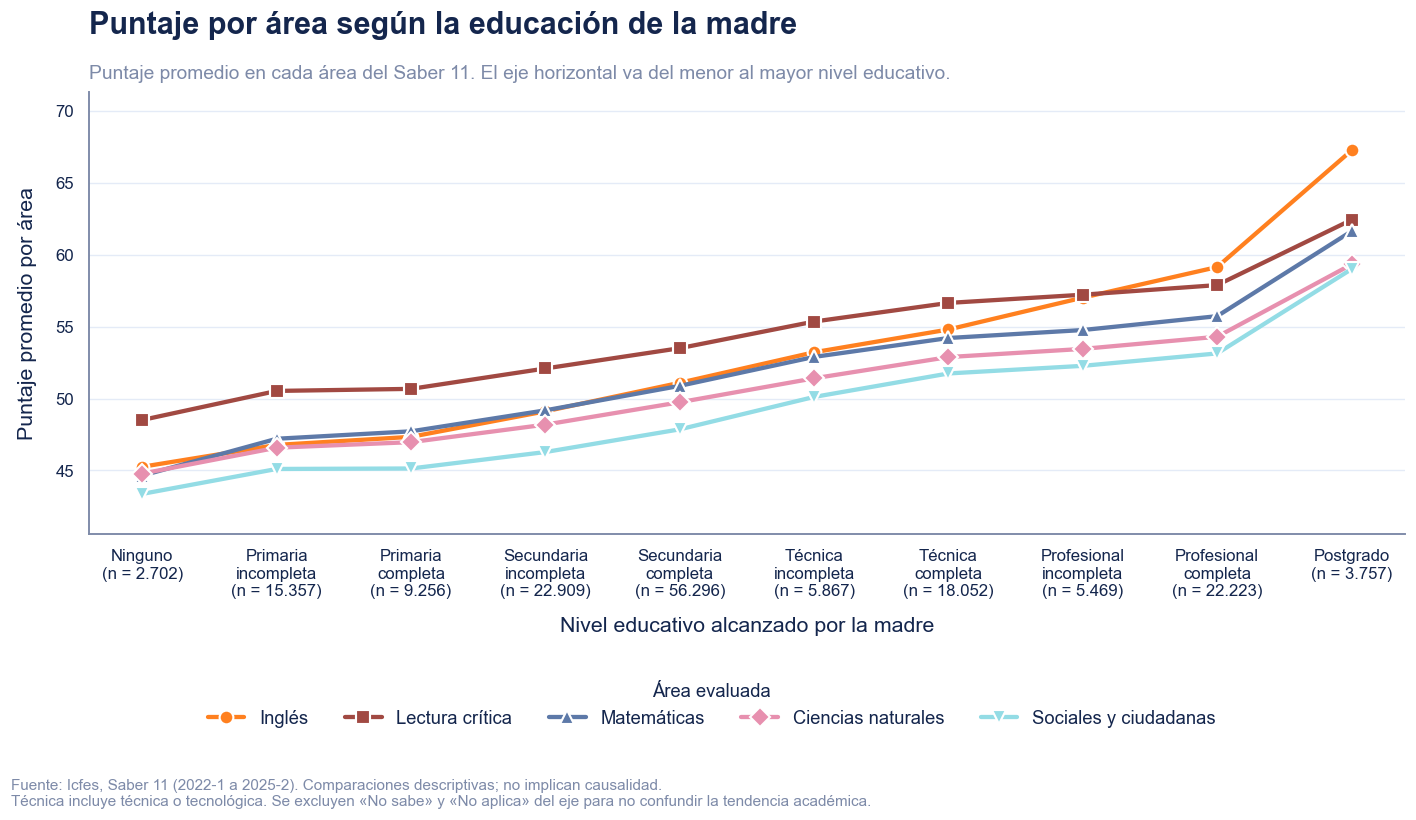

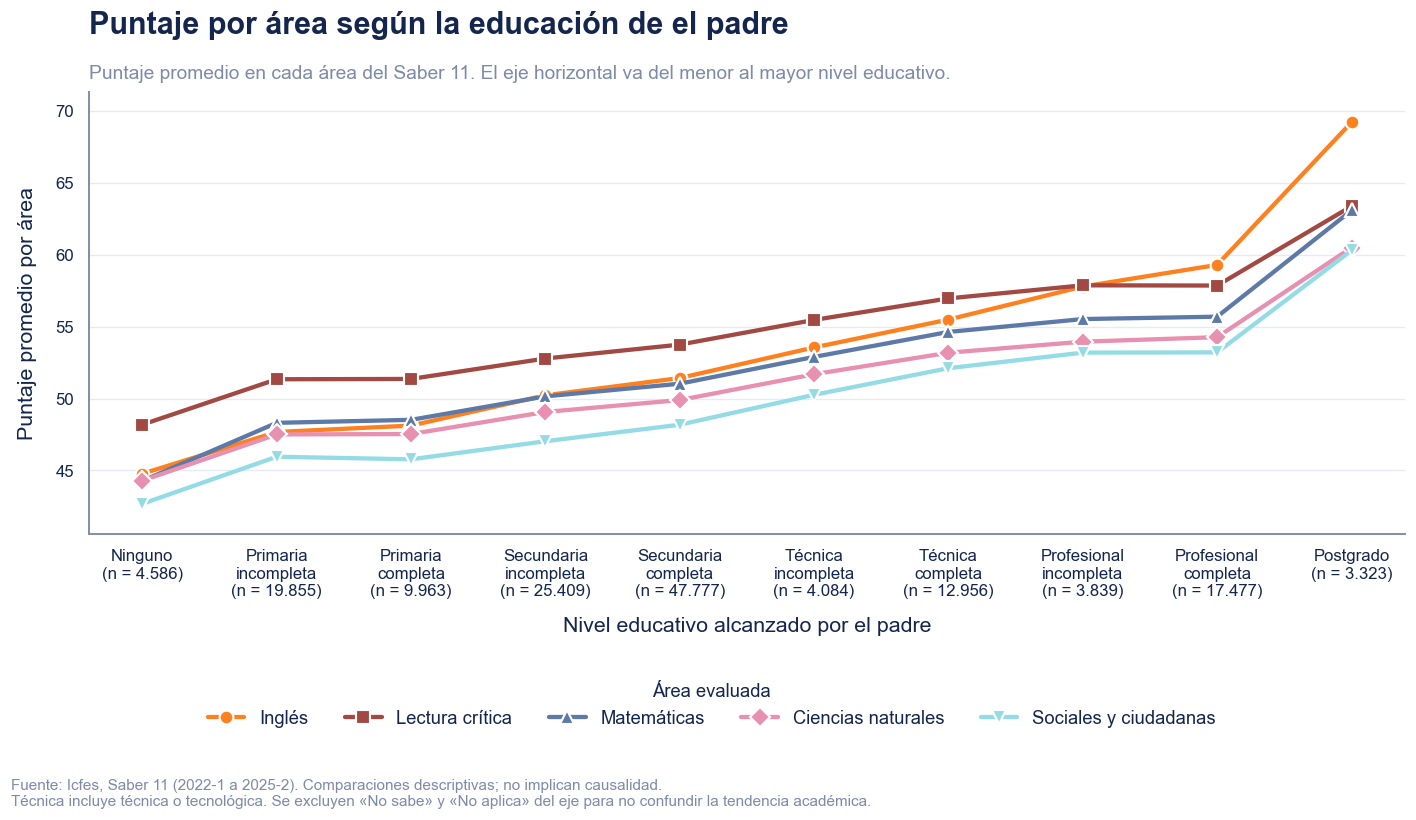

Diferencia descriptiva entre postgrado y ningún nivel educativo:


,Madre: postgrado - ninguno,Padre: postgrado - ninguno
Inglés,21.97,24.41
Lectura crítica,13.90,15.17
Matemáticas,16.97,18.79
Ciencias naturales,14.53,16.19
Sociales y ciudadanas,15.61,17.60


Promedios por nivel educativo de la madre:


,Inglés,Lectura crítica,Matemáticas,Ciencias naturales,Sociales y ciudadanas
nivel_educativo,,,,,
Ninguno,45.26,48.51,44.65,44.79,43.37
Primaria\nincompleta,46.77,50.53,47.20,46.58,45.11
Primaria\ncompleta,47.34,50.67,47.72,46.97,45.14
Secundaria\nincompleta,49.11,52.09,49.18,48.19,46.28
Secundaria\ncompleta,51.09,53.50,50.88,49.74,47.86
Técnica\nincompleta,53.21,55.35,52.89,51.40,50.11
Técnica\ncompleta,54.79,56.64,54.20,52.88,51.74
Profesional\nincompleta,57.01,57.21,54.76,53.45,52.27
Profesional\ncompleta,59.13,57.88,55.72,54.29,53.13


Cantidad de estudiantes por nivel educativo de la madre:


,estudiantes
nivel_educativo,
Ninguno,2702
Primaria\nincompleta,15357
Primaria\ncompleta,9256
Secundaria\nincompleta,22909
Secundaria\ncompleta,56296
Técnica\nincompleta,5867
Técnica\ncompleta,18052
Profesional\nincompleta,5469
Profesional\ncompleta,22223


Promedios por nivel educativo del padre:


,Inglés,Lectura crítica,Matemáticas,Ciencias naturales,Sociales y ciudadanas
nivel_educativo,,,,,
Ninguno,44.78,48.19,44.28,44.29,42.69
Primaria\nincompleta,47.67,51.34,48.31,47.50,45.96
Primaria\ncompleta,48.12,51.36,48.52,47.53,45.78
Secundaria\nincompleta,50.22,52.78,50.15,49.06,47.03
Secundaria\ncompleta,51.42,53.74,51.03,49.89,48.18
Técnica\nincompleta,53.55,55.46,52.89,51.69,50.26
Técnica\ncompleta,55.48,56.95,54.62,53.18,52.11
Profesional\nincompleta,57.78,57.86,55.52,53.95,53.19
Profesional\ncompleta,59.28,57.85,55.68,54.26,53.21


Cantidad de estudiantes por nivel educativo del padre:


,estudiantes
nivel_educativo,
Ninguno,4586
Primaria\nincompleta,19855
Primaria\ncompleta,9963
Secundaria\nincompleta,25409
Secundaria\ncompleta,47777
Técnica\nincompleta,4084
Técnica\ncompleta,12956
Profesional\nincompleta,3839
Profesional\ncompleta,17477


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgb

# 1. Paleta, estilo y utilidades
PALETA_A = ["#FF6F00","#C71000", "#008EA0", "#8A4198", "#FF95A8", "#84D7E1"]
TXT_A = "#14264d"    # azul marino: títulos, ejes y contornos
GRS_A = "#7d8aa8"    # subtítulos y notas
GRD_A = "#e4ebf7"    # rejilla suave

fuente = ("Fuente: Icfes, Saber 11 (2022-1 a 2025-2). Comparaciones descriptivas; no implican causalidad.\n"
          "Técnica incluye técnica o tecnológica. Se excluyen «No sabe» y «No aplica» del eje "
          "para no confundir la tendencia académica.")

cmap_a = LinearSegmentedColormap.from_list("azul_cian", PALETA_A)

def colores_a(n, suavizar=0.0):
    """n colores equidistantes de la gama; 'suavizar' los mezcla con blanco (tono pastel)."""
    lista = []
    for v in np.linspace(0, 1, n):
        rgb = np.array(to_rgb(cmap_a(v)))
        lista.append(tuple(rgb + (1 - rgb) * suavizar))
    return lista

def miles(v):
    return f"{int(v):,}".replace(",", ".")

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "text.color": TXT_A,
    "axes.labelcolor": TXT_A,
    "axes.edgecolor": GRS_A,
    "xtick.color": TXT_A,
    "ytick.color": TXT_A,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRD_A,
    "grid.linewidth": 0.9,
})

def titulo_a(ax, principal, subtitulo):
    ax.set_title(principal, loc="left", fontsize=20, fontweight="bold", pad=38)
    ax.text(0, 1.03, subtitulo, transform=ax.transAxes, fontsize=12.5, color=GRS_A)

# 2. Categorías y resumen por nivel educativo

orden_educacion = [
    "ninguno", "primariaincompleta", "primariacompleta",
    "secundariabachilleratoincompleta", "secundariabachilleratocompleta",
    "tecnicaotecnologicaincompleta", "tecnicaotecnologicacompleta",
    "educacionprofesionalincompleta", "educacionprofesionalcompleta",
    "postgrado", "nosabe", "noaplica",
]

# Etiquetas más cortas para que quepan las 10 categorías en una figura de ancho completo
etiquetas_educacion = {
    "ninguno": "Ninguno",
    "primariaincompleta": "Primaria\nincompleta",
    "primariacompleta": "Primaria\ncompleta",
    "secundariabachilleratoincompleta": "Secundaria\nincompleta",
    "secundariabachilleratocompleta": "Secundaria\ncompleta",
    "tecnicaotecnologicaincompleta": "Técnica\nincompleta",
    "tecnicaotecnologicacompleta": "Técnica\ncompleta",
    "educacionprofesionalincompleta": "Profesional\nincompleta",
    "educacionprofesionalcompleta": "Profesional\ncompleta",
    "postgrado": "Postgrado",
    "nosabe": "No sabe",
    "noaplica": "No aplica",
}

nombres_areas = {
    "punt_ingles": "Inglés",
    "punt_lectura_critica": "Lectura crítica",
    "punt_matematicas": "Matemáticas",
    "punt_c_naturales": "Ciencias naturales",
    "punt_sociales_ciudadanas": "Sociales y ciudadanas",
}

niveles_academicos = orden_educacion[:10]
etiquetas_academicas = [etiquetas_educacion[nivel] for nivel in niveles_academicos]

def resumen_educacion(variable):
    base = df[[variable, *nombres_areas]].dropna(subset=[variable]).copy()
    base[variable] = base[variable].astype(str)
    sin_etiqueta = sorted(set(base[variable].unique()) - set(etiquetas_educacion))
    if sin_etiqueta:
        print(f"Aviso ({variable}): categorías sin etiqueta, excluidas del resumen -> {sin_etiqueta}")
    base["nivel_educativo"] = base[variable].map(etiquetas_educacion)
    orden_etiquetas = [etiquetas_educacion[nivel] for nivel in orden_educacion]

    grupos = base.groupby("nivel_educativo")[list(nombres_areas)]
    promedio = grupos.mean().reindex(orden_etiquetas).rename(columns=nombres_areas)
    cantidad = grupos.count().reindex(orden_etiquetas).rename(columns=nombres_areas)
    return promedio, cantidad

promedio_madre, n_madre = resumen_educacion("fami_educacionmadre")
promedio_padre, n_padre = resumen_educacion("fami_educacionpadre")

# 3. Colores, marcadores y escala compartida

# Un color por área; como son tonos cercanos, cada área lleva además un marcador distinto
colores_areas = dict(zip(nombres_areas.values(), colores_a(len(nombres_areas), suavizar=0.12)))
marcadores_areas = dict(zip(nombres_areas.values(), ["o", "s", "^", "D", "v"]))

# Misma escala vertical en las dos figuras para poder compararlas
todos = pd.concat([promedio_madre.loc[etiquetas_academicas], promedio_padre.loc[etiquetas_academicas]])
y_min, y_max = todos.min().min(), todos.max().max()
margen = (y_max - y_min) * 0.08


# 4. Figuras: una por progenitor
def figura_educacion(promedio, cantidad, progenitor, archivo):
    n_por_nivel = cantidad.loc[etiquetas_academicas].max(axis=1)
    x = np.arange(len(etiquetas_academicas))

    fig, ax = plt.subplots(figsize=(13, 7.5))
    for area in nombres_areas.values():
        ax.plot(x, promedio.loc[etiquetas_academicas, area],
                color=colores_areas[area], marker=marcadores_areas[area],
                markersize=9, linewidth=2.8, markeredgecolor="white",
                markeredgewidth=1.4, label=area)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{e}\n(n = {miles(n)})" for e, n in zip(etiquetas_academicas, n_por_nivel)],
                       fontsize=11)
    ax.set_xlim(-0.4, len(x) - 0.6)
    ax.set_ylim(y_min - margen, y_max + margen)
    ax.set_xlabel(f"Nivel educativo alcanzado por {progenitor}", fontsize=14, labelpad=12)
    ax.set_ylabel("Puntaje promedio por área", fontsize=14, labelpad=12)
    ax.grid(axis="x", visible=False)

    titulo_a(ax, f"Puntaje por área según la educación de {progenitor}",
             "Puntaje promedio en cada área del Saber 11. El eje horizontal va del menor al mayor nivel educativo.")

    fig.legend(*ax.get_legend_handles_labels(), loc="lower center", bbox_to_anchor=(0.5, 0.085),
               ncol=5, frameon=False, fontsize=12, title="Área evaluada", title_fontsize=12)
    fig.text(0.01, 0.01, fuente, fontsize=10, color=GRS_A)
    fig.tight_layout(rect=[0, 0.19, 1, 1])
    # fig.savefig(archivo, dpi=300, bbox_inches="tight")
    plt.show()

figura_educacion(promedio_madre, n_madre, "la madre", "fig_educacion_madre.png")
figura_educacion(promedio_padre, n_padre, "el padre", "fig_educacion_padre.png")

# ─────────────────────────────────────────────
# 5. Tablas de apoyo
# ─────────────────────────────────────────────
# Tabla descriptiva completa, incluyendo las respuestas no académicas.
comparacion = pd.DataFrame({
    "Madre: postgrado - ninguno": promedio_madre.loc["Postgrado"] - promedio_madre.loc["Ninguno"],
    "Padre: postgrado - ninguno": promedio_padre.loc["Postgrado"] - promedio_padre.loc["Ninguno"],
})

print("Diferencia descriptiva entre postgrado y ningún nivel educativo:")
display(comparacion.round(2))

print("Promedios por nivel educativo de la madre:")
display(promedio_madre.round(2))
print("Cantidad de estudiantes por nivel educativo de la madre:")
display(n_madre.iloc[:, 0].rename("estudiantes").to_frame())

print("Promedios por nivel educativo del padre:")
display(promedio_padre.round(2))
print("Cantidad de estudiantes por nivel educativo del padre:")
display(n_padre.iloc[:, 0].rename("estudiantes").to_frame())

Nuestros datos corrobaran la literatura consultada: el rendimiento del estudiante tiene una dependencia con el nivel educativo de sus progenitores